In [ ]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 3.3 MB/s eta 0:00:00


In [ ]:
import os
import gc
import torch
import random
import pickle
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import imageio.v2 as imageio
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from scipy.stats import qmc
from google.colab import drive
from torch.multiprocessing import Pool
from deap.tools import sortNondominated
from sklearn.preprocessing import MinMaxScaler
from transformers import GPT2Config, GPT2LMHeadModel, GPT2Tokenizer
from torch.profiler import profile, record_function, ProfilerActivity

# S-Metric Selection Multi Objective Differential Evolution Strategy.

In [ ]:
def pop_gen(size, n_var, bounds, is_real=True, n_obj=1):
  pop = []
  for i in range(size):
    individual = [random.uniform(bounds[j][0], bounds[j][1]) if is_real else random.choice(range(bounds[j][0], bounds[j][1] + 1)) for j in range(n_var)]
    pop.append({'individual': individual, 'fitness': [0 for _ in range(n_obj)]})
  return pop

In [ ]:
pop = pop_gen(5, 2, [(1, 10), (-10, 10)], is_real=False, n_obj=2)
pop

[{'individual': [10, 8], 'fitness': [0, 0]},
 {'individual': [2, 10], 'fitness': [0, 0]},
 {'individual': [2, -7], 'fitness': [0, 0]},
 {'individual': [10, 5], 'fitness': [0, 0]},
 {'individual': [8, -2], 'fitness': [0, 0]}]

In [ ]:
def map_to_unit(value, domain):
    if isinstance(domain, tuple):
        min_i, max_i = domain
        r = (value - min_i) / (max_i - min_i)
        return r
    elif isinstance(domain, list):
        index = domain.index(value)
        r = index / (len(domain) - 1)
        return r
    else:
        raise ValueError("Invalid domain")

def map_from_unit(r, domain):
    if isinstance(domain, tuple):
        min_i, max_i = domain
        value = min_i + r * (max_i - min_i)
        if isinstance(min_i, int) and isinstance(max_i, int):
            value = int(round(value))
        return value
    elif isinstance(domain, list):
        index = int(round(r * (len(domain) - 1)))
        index = min(max(index, 0), len(domain) - 1)  # Ensure index is within bounds
        value = domain[index]
        return value
    else:
        raise ValueError("Invalid domain")

In [ ]:
def map_vector_to_unit(vector, domains):
    return [map_to_unit(value, domain) for value, domain in zip(vector, domains)]

def map_vector_from_unit(vector, domains):
    return [map_from_unit(r, domain) for r, domain in zip(vector, domains)]

In [ ]:
print(pop[0]['individual'])
real_vec = map_vector_to_unit(pop[0]['individual'], [(1, 10), (-10, 10)])
print(real_vec)
back_to_int = map_vector_from_unit(real_vec, [(1, 10), (-10, 10)])
print(back_to_int)

In [ ]:
def get_cr_points(rp, n):
  indexes = list(range(n))
  j_star = random.sample(indexes, n // 2)

  for j in range(n):
    if random.random() < rp and j not in j_star:
      j_star.append(j)

  return j_star

In [ ]:
class FitnessValue:
    """A wrapper for fitness values with a `dominates()` method for DEAP compatibility."""
    def __init__(self, values):
        self.values = torch.tensor(values, dtype=torch.float32, device="cuda" if torch.cuda.is_available() else "cpu")

    def dominates(self, other):
        """Check if this fitness dominates another using PyTorch tensors."""
        better_in_all = torch.all(self.values <= other.values)
        strictly_better_in_any = torch.any(self.values < other.values)
        return better_in_all and strictly_better_in_any

class FitnessWrapper:
    """Wraps an individual's fitness in an object with DEAP-compatible `.fitness`."""
    def __init__(self, individual, fitness):
        self.individual = individual  # Store reference to the individual
        self.fitness = FitnessValue(fitness)  # Wrap fitness in a compatible class

def non_dominated_sorting(population, verbose=False):
    """Use DEAP's fast non-dominated sorting with correct indexing."""

    # Create a mapping from FitnessWrapper to original individuals
    wrapper_to_original = {}

    fitness_wrappers = []
    for ind in population:
        wrapped = FitnessWrapper(ind, ind['fitness'])
        fitness_wrappers.append(wrapped)
        wrapper_to_original[wrapped] = ind  # Map wrapper back to original individual

    # Perform non-dominated sorting
    fronts = sortNondominated(fitness_wrappers, len(population), first_front_only=False)

    # Convert DEAP front indices back to the original population
    return [[wrapper_to_original[ind] for ind in front] for front in fronts]

In [ ]:
def calculate_hypervolume(front, reference_point, objectives):
    # Transform the front and reference point according to the objectives
    transformed_front = [
        {'individual': x['individual'], 'fitness': [-x['fitness'][0] if objectives[0] == "max" else x['fitness'][0], x['fitness'][1] if objectives[1] == "min" else -x['fitness'][1]]}
        for x in front
    ]

    #print("Trans front is", transformed_front)

    # Sort the transformed front by the first objective, breaking ties with the second objective
    sorted_front = sorted(transformed_front, key=lambda x: (x['fitness'][0], -x['fitness'][1]))
    #print("Sorted front is", sorted_front)

    hypervolume = 0.0
    previous_f2 = reference_point[1]

    for solution in sorted_front:
        f1, f2 = solution['fitness']
        width = reference_point[0] - f1
        height = previous_f2 - f2
        hypervolume += width * height
        previous_f2 = f2  # Update the lower boundary for the next solution

    return hypervolume

In [ ]:
def calculate_reference_point(population, objectives, margin=0.1):
    num_objectives = len(population[0]['fitness'])  # Assume all individuals have the same number of objectives
    reference_point = []

    for obj_idx in range(num_objectives):
        if objectives[obj_idx] == "min":
            # For minimization objectives, use max + margin
            max_value = max(individual['fitness'][obj_idx] for individual in population)
            reference_point.append(max_value + margin)
        elif objectives[obj_idx] == "max":
            # For maximization objectives, use -(min - margin)
            min_value = min(-individual['fitness'][obj_idx] for individual in population)
            reference_point.append(-(min_value - margin))
        else:
            raise ValueError(f"Objective type must be 'min' or 'max', but got {objectives[obj_idx]}.")

    return reference_point

In [ ]:
def sms_emoa_step(population, objectives, reference_point, z, verbose=False):
    # Step 1: Non-Dominated Sorting
    if verbose:
      print(f'Initial pop size before nsga: {len(population)}')
    fronts = non_dominated_sorting(population, verbose=verbose)
    if verbose:
      print(f"🔍 Number of non-dominated fronts found: {len(fronts)}")

      for i, front in enumerate(fronts):
          print(f"  🔹 Front {i} has {len(front)} individuals")

    # Step 2: Flatten All Fronts into a Single List
    flattened_population = []
    for front_indices in fronts:
        flattened_population.extend([population[i] for i in front_indices])

    # 🚨 Ensure we have at least `z` individuals
    if len(flattened_population) < z:
        additional_needed = z - len(flattened_population)
        if verbose:
          print(f"⚠️ Warning: Flattened population has only {len(flattened_population)} individuals, filling up with {additional_needed} more.")
        additional_random = random.sample(population, additional_needed)
        flattened_population.extend(additional_random)

    if verbose:
      print(f"⚠️ Flattened population size: {len(flattened_population)} (Expected: {z})")

    # Step 3: Calculate Hypervolume Contributions for Each Individual
    hypervolume_contributions = []
    total_hypervolume = calculate_hypervolume(flattened_population, reference_point, objectives)
    #print("Total hypervolume is", total_hypervolume)

    for i, solution in enumerate(flattened_population):
        # Remove solution from the population temporarily to compute exclusive hypervolume
        temp_population = flattened_population[:i] + flattened_population[i+1:]
        hypervolume_without_solution = calculate_hypervolume(temp_population, reference_point, objectives)
        contribution = total_hypervolume - hypervolume_without_solution
        #print("Contribution of", solution, "is", contribution)
        hypervolume_contributions.append((contribution, solution))

    # Step 4: Sort All Individuals by Their Hypervolume Contribution (Descending Order)
    hypervolume_contributions.sort(key=lambda x: x[0], reverse=True)

    # Step 5: Select the Top z Individuals
    selected_population = [entry[1] for entry in hypervolume_contributions[:z]]

    return selected_population

In [ ]:
population = [
    {'individual': [1, 3], 'fitness': [0.2, 0.8]},
    {'individual': [3, 3], 'fitness': [0.4, 0.4]},
    {'individual': [0, 8], 'fitness':[0.3, 0.5]},
    {'individual': [1, 1], 'fitness':[0.7, 0.7]},
    {'individual': [1, 0], 'fitness':[0.9, 0.6]}
]

objectives = ["min", "max"]
reference_point = calculate_reference_point(population, objectives)
print("Reference point is", reference_point)

print("Initial Population:", population)
updated_population = sms_emoa_step(population, objectives, reference_point, z=len(population)-1)
print("Updated Population:", updated_population)

Reference point is [1.0, 0.9]
Initial Population: [{'individual': [1, 3], 'fitness': [0.2, 0.8]}, {'individual': [3, 3], 'fitness': [0.4, 0.4]}, {'individual': [0, 8], 'fitness': [0.3, 0.5]}, {'individual': [1, 1], 'fitness': [0.7, 0.7]}, {'individual': [1, 0], 'fitness': [0.9, 0.6]}]
Updated Population: [{'individual': [1, 3], 'fitness': [0.2, 0.8]}, {'individual': [1, 1], 'fitness': [0.7, 0.7]}, {'individual': [1, 0], 'fitness': [0.9, 0.6]}, {'individual': [3, 3], 'fitness': [0.4, 0.4]}]


In [ ]:
print("Initial Population:", population)
updated_population = sms_emoa_step(population, objectives, reference_point, z=1)
print("Updated Population:", updated_population)

Initial Population: [{'individual': [1, 3], 'fitness': [0.2, 0.8]}, {'individual': [3, 3], 'fitness': [0.4, 0.4]}, {'individual': [0, 8], 'fitness': [0.3, 0.5]}, {'individual': [1, 1], 'fitness': [0.7, 0.7]}, {'individual': [1, 0], 'fitness': [0.9, 0.6]}]
Updated Population: [{'individual': [1, 3], 'fitness': [0.2, 0.8]}]


In [ ]:
def get_succ_m(parents, children):
  # Count if mutation was successful than the average parent fitness
  parent_fitness_f1 = [parent['fitness'][0] for parent in parents]
  parent_fitness_f2 = [parent['fitness'][1] for parent in parents]
  avg_fitness_f1 = np.mean(parent_fitness_f1)
  avg_fitness_f2 = np.mean(parent_fitness_f2)

  succ_m_count = sum(1 for child in children if child['fitness'][0] < avg_fitness_f1 and child['fitness'][1] > avg_fitness_f2)

  return succ_m_count

In [ ]:
def dominates(ind1, ind2):
    """Return True if ind1 dominates ind2 (minimize f1, maximize f2)."""
    f1_1, f2_1 = ind1['fitness'][0], ind1['fitness'][1]
    f1_2, f2_2 = ind2['fitness'][0], ind2['fitness'][1]
    return f1_1 <= f1_2 and f2_1 >= f2_2 and (f1_1 < f1_2 or f2_1 > f2_2)

def compute_dominance_flags(population):
    """Add a 'dominated' key to each individual in the population."""
    for i, ind1 in enumerate(population):
        dominated = False
        for j, ind2 in enumerate(population):
            if i != j and dominates(ind2, ind1):
                dominated = True
                break
        ind1['dominated'] = dominated
    return population

def save_pareto_plot(population, generation, plot_dir):
    """Save Pareto plot where METEOR score is inverted and dominance is visualized."""

    # Mark each individual as dominated or not
    population = compute_dominance_flags(population)

    # Extract and normalize f1
    f1_values = np.array([ind['fitness'][0] for ind in population])
    f1_values_norm = MinMaxScaler((0, 1)).fit_transform(f1_values.reshape(-1, 1)).flatten()

    # Extract and invert f2 (METEOR)
    f2_values = np.array([-ind['fitness'][1] for ind in population])  # Invert METEOR

    # Split by dominance
    non_dominated = [i for i in range(len(population)) if not population[i]['dominated']]
    dominated = [i for i in range(len(population)) if population[i]['dominated']]

    plt.figure(figsize=(8, 6))
    if dominated:
        plt.scatter(f1_values_norm[dominated], f2_values[dominated], c="blue", label="Dominated")
    if non_dominated:
        plt.scatter(f1_values_norm[non_dominated], f2_values[non_dominated], c="red", label="Non-Dominated")

    plt.xlim(0, 1)
    plt.ylim(-1, 0)
    plt.xlabel("Normalized # of Parameters")
    plt.ylabel("Inverted METEOR Score (-1 * METEOR)")
    plt.title(f"Population at Generation {generation + 1}")
    plt.legend()
    plt.grid(True)

    # Save plot
    plt.savefig(f"{plot_dir}/generation_{generation:03d}.png")
    plt.close()

In [ ]:
def select_best_individuals(complete_pop, objectives, reference_point, z):
  hypervol_contribs = torch.tensor(
      [calculate_hypervolume([ind], reference_point, objectives) for ind in complete_pop],
      dtype=torch.float32,
      device="cuda" if torch.cuda.is_available() else "cpu"
  )

  sorted_indices = torch.argsort(hypervol_contribs, descending=True)
  return [complete_pop[i] for i in sorted_indices[:z].tolist()]

In [ ]:
def check_convergence(best_fitness_per_gen, gen, check_interval=50, target_meteor=0.85, tolerance=0.15):
    """
    Every `check_interval` generations, check if the current generation's
    mean METEOR Score is within `target_meteor ± tolerance`.
    """

    # Only check every `check_interval` generations
    if gen % check_interval != 0:
        return False  # Keep running

    # Extract METEOR scores (f2 values) from the current generation
    meteor_score = best_fitness_per_gen[1]
    print(f'({target_meteor - tolerance}) <= {meteor_score} <= ({target_meteor + tolerance})')

    # Check if mean METEOR score is within target range
    return (target_meteor - tolerance) <= meteor_score <= (target_meteor + tolerance)

In [ ]:
def cleanup_memory():
  torch.cuda.empty_cache()
  gc.collect()

In [ ]:
def compute_fitness(individual, target_funcs):
    """Compute fitness for a single individual in parallel processing."""
    return [func(individual) for func in target_funcs]

In [ ]:
def evaluate_fitness_parallel(population, target_funcs):
    """Parallelized fitness evaluation for batch processing."""
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # Convert population into a tensor for GPU processing
    pop_tensor = torch.tensor([ind['individual'] for ind in population], dtype=torch.float32, device=device)

    # Compute fitness in parallel using Pool
    with Pool(processes=max(1, os.cpu_count())) as pool:
        fitness_results = pool.starmap(compute_fitness, [(ind, target_funcs) for ind in pop_tensor.cpu().numpy()])  # ✅ Fix applied

    # Assign fitness values
    for i, ind in enumerate(population):
        ind['fitness'] = fitness_results[i]

    return population

In [ ]:
def lexsms_modes(target_funcs, domains, repair, n_var=1, n_obj=1, objectives=["min", "max"],
              mu=10, lamb=1, F=2, rp=0.5, gens=100, n=10, auto_adapt=False, is_real=True, nas=False, save_progress=False, early_conv=False):
  device = "cuda" if torch.cuda.is_available() else "cpu"
  print(f"Using device: {device}")

  # Initialize parent population
  if(nas):
    pop = pop_gen(mu)
  else:
    pop = pop_gen(mu, n_var, domains, is_real, n_obj)

  succ_m_count = 0
  best_fitness_per_gen = []
  Fs = []
  gens_dict = {}

  # Move population to GPU
  pop_tensors = torch.tensor([ind['individual'] for ind in pop], dtype=torch.float32, device=device)

  # Calc fitness
  pop = evaluate_fitness_parallel(pop, target_funcs)

  reference_point = calculate_reference_point(pop, objectives)

  with tqdm(total=gens, desc="Generations", leave=True) as pbar_gens:
    for gen in range(gens):
      children = []

      # Move population fitness to GPU
      pop_fitness = torch.tensor([ind['fitness'] for ind in pop], dtype=torch.float32, device=device)

      #  Select best parent via non-dominated sorting
      best_parents = non_dominated_sorting(pop)
      best_parent = best_parents[0][0]

      for i in range(lamb):
        parent = pop[i]['individual']
        best_parent_unit = map_vector_to_unit(best_parent['individual'], domains)

        # Mutation and repair mechanism
        x2, x3 = random.choices(pop, k=2)
        x2_tensor = torch.tensor(map_vector_to_unit(x2['individual'], domains), dtype=torch.float32, device=device)
        x3_tensor = torch.tensor(map_vector_to_unit(x3['individual'], domains), dtype=torch.float32, device=device)

        best_parent_unit_tensor = torch.tensor(best_parent_unit, dtype=torch.float32, device=device)
        u = best_parent_unit_tensor + F * (x2_tensor - x3_tensor)
        u_numpy = u.cpu().numpy()
        u = repair(map_vector_from_unit(u_numpy, domains))

        # Recombination
        cr_points = get_cr_points(rp, len(parent))
        child = [u[j] if j in cr_points else parent[j] for j in range(len(u))]
        child = repair(child)
        children.append({ 'individual': child, 'fitness': [0 for _ in range(n_obj)]})

      # Calc fitness of children
      children = evaluate_fitness_parallel(children, target_funcs)

      # Select the best mu elements for next gen
      complete_pop = pop + children

      # Map population to original values
      complete_pop = [
          {'individual': map_vector_from_unit(ind['individual'], domains), 'fitness': ind['fitness']}
          if isinstance(ind['individual'][0], float) else ind
          for ind in complete_pop
        ]

      pop = select_best_individuals(complete_pop, objectives, reference_point, mu)

      if(auto_adapt):
        # Count succesful mutations
        succ_m_count += get_succ_m(pop, children)

        # During each time window (n) self-adapt F
        if (gen + 1) % n == 0:
          ps = succ_m_count / (n * lamb)

          if ps > 1/5:
            F /= 0.817
          elif ps < 1/5:
            F *= 0.817

          succ_m_count = 0

      Fs.append(F)
      best_fitness_per_gen.append([pop[0]['fitness'][0], pop[0]['fitness'][1]])

      if save_progress:
        gens_dict[gen] = pop

      # Cleanup memory
      cleanup_memory()

      # Check for early stopping
      if early_conv and check_convergence(best_fitness_per_gen[gen], gen):
        print("Convergence reached, stopping early")
        break

      pbar_gens.update(1)

  best_element = select_best_individuals(pop, objectives, reference_point, 1)
  Fs.append(F)
  return best_element, best_fitness_per_gen, Fs, gens_dict

In [ ]:
def create_gif(plot_dir, gens_dict, output_file="pareto_evolution.gif", fps=5):
    """Create an animation from saved Pareto front images and plot mean hypervolume per generation."""

    os.makedirs(plot_dir, exist_ok=True)

    # Store all hypervolume values per generation
    hypervolume_log = []

    for gen in gens_dict:
        pop = gens_dict[gen]

        # Save plot with updated color coding & METEOR inversion
        save_pareto_plot(pop, gen, plot_dir)

        # Normalize f1 and invert f2 for hypervolume calculation
        f1_vals = np.array([ind['fitness'][0] for ind in pop])
        f2_vals = np.array([-ind['fitness'][1] for ind in pop])  # Inverted METEOR
        f1_scaled = MinMaxScaler((0, 1)).fit_transform(f1_vals.reshape(-1, 1)).flatten()

        points = np.column_stack((f1_scaled, f2_vals))

        # Sort for hypervolume approximation via trapezoidal rule
        points = points[np.argsort(points[:, 0])]
        hv = 0.0
        for i in range(len(points) - 1):
            width = points[i + 1][0] - points[i][0]
            height = -min(points[i][1], points[i + 1][1])
            hv += width * height
        hypervolume_log.append(hv)

    # Convert plots into GIF
    file_list = sorted([f for f in os.listdir(plot_dir) if f.endswith(".png") and f.startswith("generation")])
    images = []

    target_size = Image.open(os.path.join(plot_dir, file_list[0])).size

    for filename in file_list:
        img = Image.open(os.path.join(plot_dir, filename)).resize(target_size)
        images.append(img)

    images[0].save(os.path.join(plot_dir, output_file), save_all=True, append_images=images[1:], duration=int(1000/ fps))
    print(f"🔥 Animation saved as {output_file}")

    # Plot mean hypervolume progression
    gens = list(gens_dict.keys())
    hv_arr = np.array(hypervolume_log)
    mean_hv = hv_arr

    plt.figure(figsize=(10, 6))
    plt.plot(gens, mean_hv, label='Mean Hypervolume', marker='o', color='purple')
    plt.title("Hypervolume Evolution Across Generations")
    plt.xlabel("Generation")
    plt.ylabel("Approximated Hypervolume")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(plot_dir, "hypervolume_progression.png"))
    plt.close()
    print("📊 Hypervolume plot saved.")


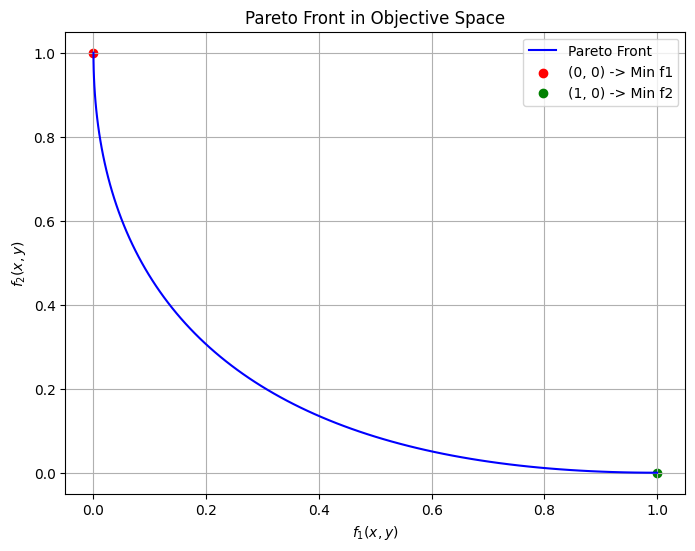

In [ ]:
# Objective functions
def f1(var):
    return var[0]**2 + var[1]**2  # Minimize distance to (0, 0)

def f2(var):
    return (var[0] - 1)**2 + var[1]**2  # Minimize distance to (1, 0)

# Define the Pareto front using f1 and f2
x_vals = np.linspace(0, 1, 100)
y_vals = np.zeros_like(x_vals)  # y = 0 along the Pareto front
variables = np.array([x_vals, y_vals])  # Combine x_vals and y_vals into an array

# Calculate objective values for Pareto front
pareto_f1_vals = np.array([f1(var) for var in variables.T])  # Transpose to iterate over pairs
pareto_f2_vals = np.array([f2(var) for var in variables.T])

# Plot the objective space (Pareto front)
plt.figure(figsize=(8, 6))
plt.plot(pareto_f1_vals, pareto_f2_vals, label="Pareto Front", color="blue")
plt.scatter(f1([0, 0]), f2([0, 0]), color="red", label="(0, 0) -> Min f1")
plt.scatter(f1([1, 0]), f2([1, 0]), color="green", label="(1, 0) -> Min f2")
plt.xlabel("$f_1(x, y)$")
plt.ylabel("$f_2(x, y)$")
plt.title("Pareto Front in Objective Space")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def repair_individual(individual, bounds=(0, 1)):
    return [np.clip(alelle, bounds[0], bounds[1]) for alelle in individual]


## Exp 1

In [ ]:
best_models = []
all_best_fitness = []
F_arr = []

for i in range(30):
  print(f'\nRunning experiment {i + 1}')

  best_element, best_fitness_per_gen, Fs = sms_modes(
      [f1, f2],
      [(0, 1), (0, 1)],
      repair_individual,
      n_var=2,
      n_obj=2,
      gens=1000
  )

  print("The best individual is", best_element)

  F_arr.append(Fs)
  best_models.append(best_element)
  all_best_fitness.append(best_fitness_per_gen)


Running experiment 1


Generations: 100%|██████████| 1000/1000 [00:01<00:00, 706.01it/s]


The best individual is [{'individual': [0.0, 1.0], 'fitness': [1.0, 2.0]}]

Running experiment 2


Generations: 100%|██████████| 1000/1000 [00:01<00:00, 546.45it/s]


The best individual is [{'individual': [0.0, 1.0], 'fitness': [1.0, 2.0]}]

Running experiment 3


...

The best individual is [{'individual': [0.0, 1.0], 'fitness': [1.0, 2.0]}]

Running experiment 29


Generations: 100%|██████████| 1000/1000 [00:01<00:00, 878.95it/s]


The best individual is [{'individual': [0.0, 1.0], 'fitness': [1.0, 2.0]}]

Running experiment 30


Generations: 100%|██████████| 1000/1000 [00:01<00:00, 754.82it/s]

The best individual is [{'individual': [0.0, 1.0], 'fitness': [1.0, 2.0]}]


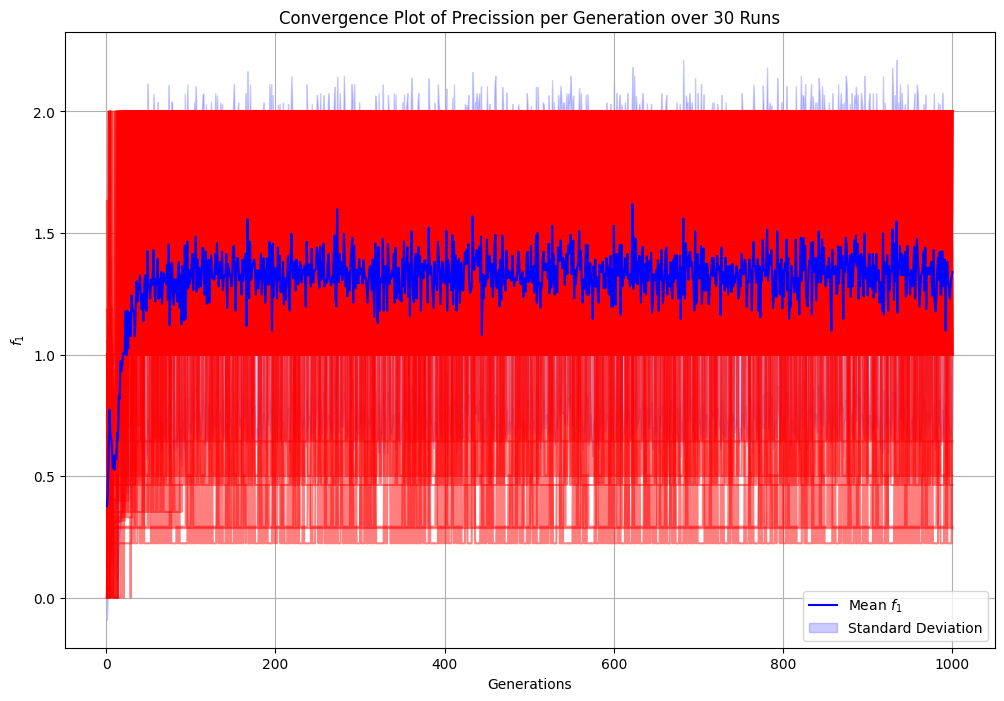

In [ ]:
# Determine the maximum number of generations across all runs
max_generations = max(len(fitness) for fitness in all_best_fitness)
generations = np.arange(1, max_generations + 1)

# Initialize a matrix to hold all fitness values, handling varying lengths
fitness_matrix = np.full((30, max_generations), np.nan)

# Separate objective values
all_best_fitness = np.array(all_best_fitness)
f1_all_runs = all_best_fitness[:, :, 0]  # All f1 values across runs and generations
f2_all_runs = all_best_fitness[:, :, 1]  # All f2 values across runs and generations

for i, best_fitness_per_gen in enumerate(f1_all_runs):
    fitness_length = len(best_fitness_per_gen)
    fitness_matrix[i, :fitness_length] = best_fitness_per_gen

# Plot all runs in red
plt.figure(figsize=(12, 8))
for i in range(30):
    plt.plot(
        generations,
        fitness_matrix[i],
        linestyle='-',
        color='red',
        alpha=0.5
    )

# Compute the mean and standard deviation across runs at each generation
mean_fitness_f1 = np.nanmean(fitness_matrix, axis=0)
std_fitness_f1 = np.nanstd(fitness_matrix, axis=0)

# Plot the mean best fitness
plt.plot(
    generations,
    mean_fitness_f1,
    linestyle='-',
    color='blue',
    label='Mean $f_1$'
)

# Fill the area between (mean - std) and (mean + std)
plt.fill_between(
    generations,
    mean_fitness_f1 - std_fitness_f1,
    mean_fitness_f1 + std_fitness_f1,
    color='blue',
    alpha=0.2,
    label='Standard Deviation'
)

plt.title('Convergence Plot of Precission per Generation over 30 Runs')
plt.xlabel('Generations')
plt.ylabel('$f_1$')
plt.legend()
plt.grid(True)
plt.show()

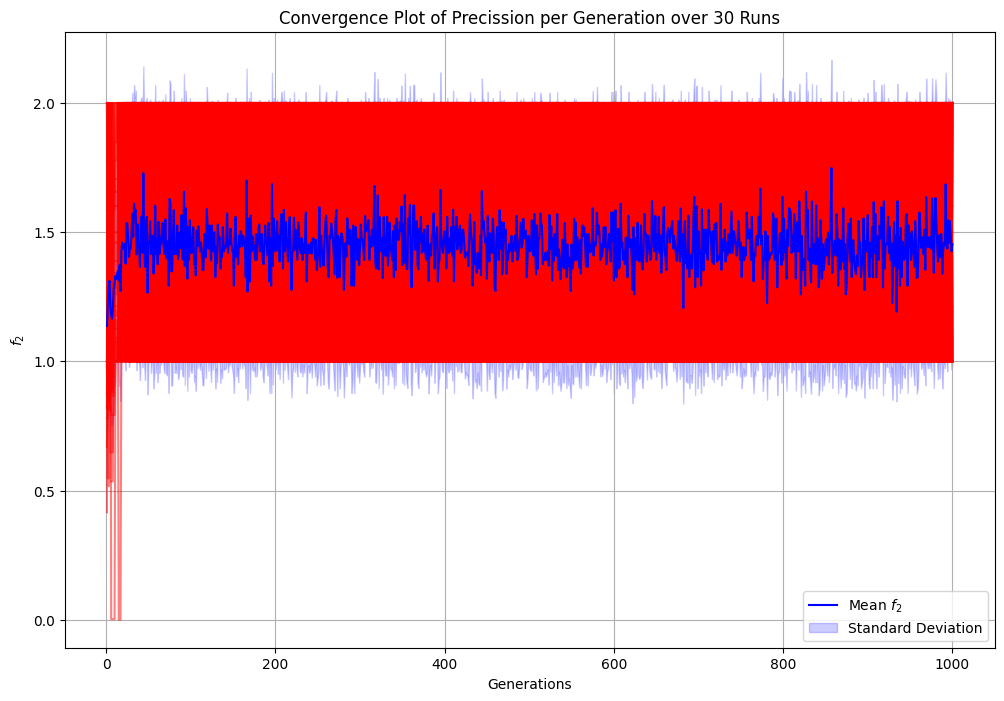

In [ ]:
# Determine the maximum number of generations across all runs
max_generations = max(len(fitness) for fitness in all_best_fitness)
generations = np.arange(1, max_generations + 1)

# Initialize a matrix to hold all fitness values, handling varying lengths
fitness_matrix = np.full((30, max_generations), np.nan)

# Separate objective values
all_best_fitness = np.array(all_best_fitness)
f1_all_runs = all_best_fitness[:, :, 0]  # All f1 values across runs and generations
f2_all_runs = all_best_fitness[:, :, 1]  # All f2 values across runs and generations

for i, best_fitness_per_gen in enumerate(f2_all_runs):
    fitness_length = len(best_fitness_per_gen)
    fitness_matrix[i, :fitness_length] = best_fitness_per_gen

# Plot all runs in red
plt.figure(figsize=(12, 8))
for i in range(30):
    plt.plot(
        generations,
        fitness_matrix[i],
        linestyle='-',
        color='red',
        alpha=0.5
    )

# Compute the mean and standard deviation across runs at each generation
mean_fitness_f2 = np.nanmean(fitness_matrix, axis=0)
std_fitness_f2 = np.nanstd(fitness_matrix, axis=0)

# Plot the mean best fitness
plt.plot(
    generations,
    mean_fitness_f2,
    linestyle='-',
    color='blue',
    label='Mean $f_2$'
)

# Fill the area between (mean - std) and (mean + std)
plt.fill_between(
    generations,
    mean_fitness_f2 - std_fitness_f2,
    mean_fitness_f2 + std_fitness_f2,
    color='blue',
    alpha=0.2,
    label='Standard Deviation'
)

plt.title('Convergence Plot of Precission per Generation over 30 Runs')
plt.xlabel('Generations')
plt.ylabel('$f_2$')
plt.legend()
plt.grid(True)
plt.show()

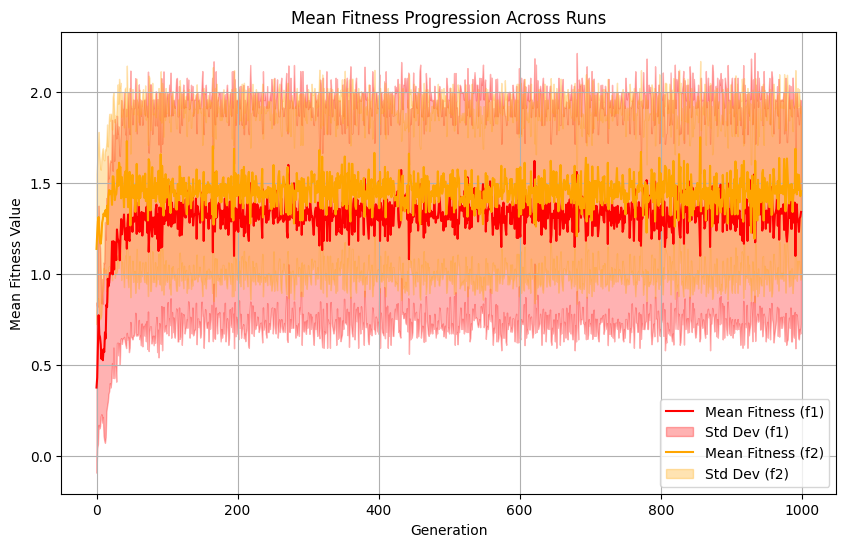

In [ ]:
# Plot 2: Mean Fitness Progression Across Runs (Both Objectives)
plt.figure(figsize=(10, 6))
plt.plot(mean_fitness_f1, label="Mean Fitness (f1)", color="red")
plt.fill_between(range(mean_fitness_f1.shape[0]), mean_fitness_f1 - std_fitness_f1, mean_fitness_f1 + std_fitness_f1, alpha=0.3, color='red', label="Std Dev (f1)")
plt.plot(mean_fitness_f2, label="Mean Fitness (f2)", color="orange")
plt.fill_between(range(mean_fitness_f2.shape[0]), mean_fitness_f2 - std_fitness_f2, mean_fitness_f2 + std_fitness_f2, alpha=0.3, color='orange', label="Std Dev (f2)")
plt.title("Mean Fitness Progression Across Runs")
plt.xlabel("Generation")
plt.ylabel("Mean Fitness Value")
plt.legend()
plt.grid()
plt.show()

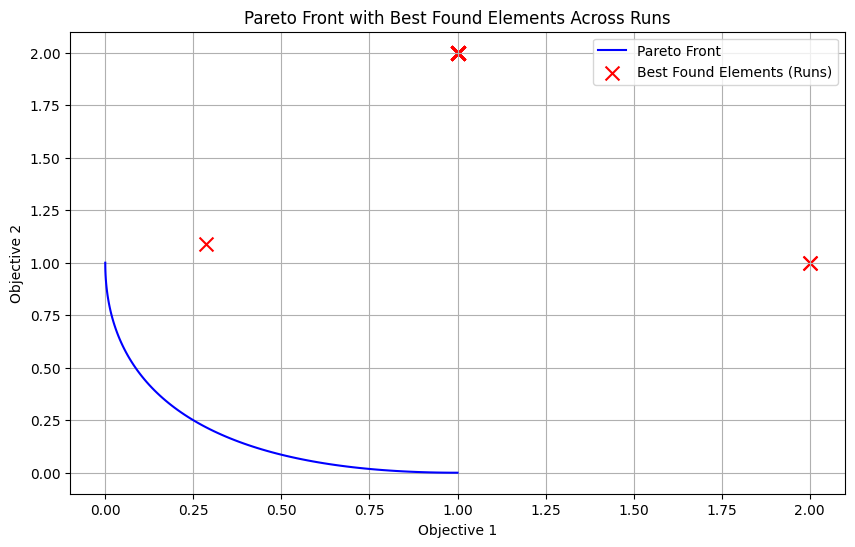

In [ ]:
# Plot 4: Pareto Front with Best Found Elements for Each Run

# Pareto front
best_elements = np.array([model[0]['fitness'] for model in best_models])  # Best models' fitness

plt.figure(figsize=(10, 6))
plt.plot(pareto_f1_vals, pareto_f2_vals, label="Pareto Front", color="blue")
plt.scatter(best_elements[:, 0], best_elements[:, 1], color="red", label="Best Found Elements (Runs)", marker="x", s=100)
plt.title("Pareto Front with Best Found Elements Across Runs")
plt.xlabel("Objective 1")
plt.ylabel("Objective 2")
plt.legend()
plt.grid()
plt.show()

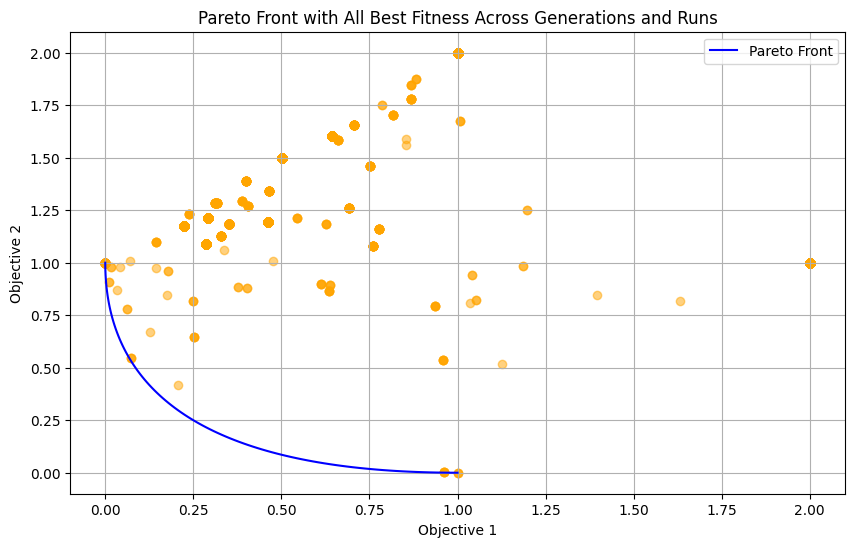

In [ ]:
# Plot 5: Pareto Front with All Best Fitness Values Across Generations for Each Run
plt.figure(figsize=(10, 6))
plt.plot(pareto_f1_vals, pareto_f2_vals, label="Pareto Front", color="blue")
for run in range(all_best_fitness.shape[0]):
    plt.scatter(f1_all_runs[run], f2_all_runs[run], color="orange", alpha=0.5)
plt.title("Pareto Front with All Best Fitness Across Generations and Runs")
plt.xlabel("Objective 1")
plt.ylabel("Objective 2")
plt.legend()
plt.grid()
plt.show()

## Exp 2

In [ ]:
best_models = []
all_best_fitness = []
F_arr = []

for i in range(30):
  print(f'\nRunning experiment {i + 1}')

  best_element, best_fitness_per_gen, Fs = sms_modes(
      [f1, f2],
      [(0, 1), (0, 1)],
      repair_individual,
      n_var=2,
      n_obj=2,
      gens=1000,
      mu=100,
      F=0.5,
      auto_adapt=True
  )

  print("The best individual is", best_element)

  F_arr.append(Fs)
  best_models.append(best_element)
  all_best_fitness.append(best_fitness_per_gen)


Running experiment 1


Generations: 100%|██████████| 1000/1000 [01:36<00:00, 10.34it/s]


The best individual is [{'individual': [0.08547337083734263, 0.6475752830876134], 'fitness': [0.4266594443883005, 1.2557127027136152]}]

Running experiment 2


Generations: 100%|██████████| 1000/1000 [01:38<00:00, 10.13it/s]


The best individual is [{'individual': [0.0, 1.0], 'fitness': [1.0, 2.0]}]

Running experiment 3


...

The best individual is [{'individual': [0.0, 1.0], 'fitness': [1.0, 2.0]}]

Running experiment 29


Generations: 100%|██████████| 1000/1000 [01:29<00:00, 11.23it/s]


The best individual is [{'individual': [0.023979420608526203, 0.8250429368650556], 'fitness': [0.6812708602836367, 1.6333120190665844]}]

Running experiment 30


Generations: 100%|██████████| 1000/1000 [01:33<00:00, 10.75it/s]


The best individual is [{'individual': [0.057926193954451755, 0.8863509438519376], 'fitness': [0.7889734396132694, 1.6731210517043658]}]


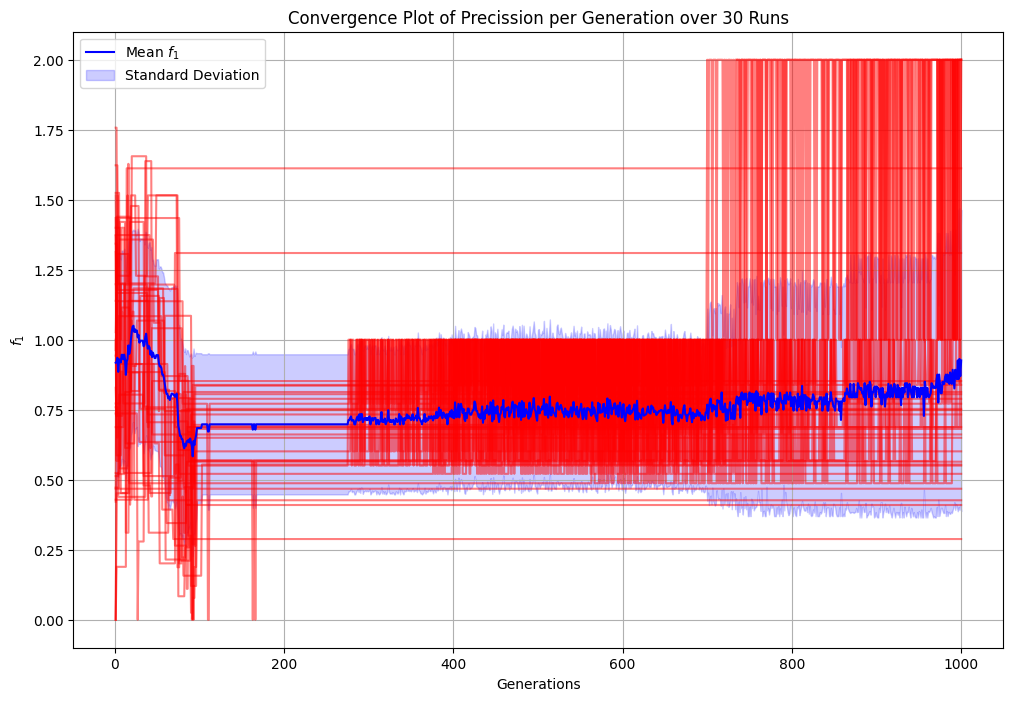

In [ ]:
# Determine the maximum number of generations across all runs
max_generations = max(len(fitness) for fitness in all_best_fitness)
generations = np.arange(1, max_generations + 1)

# Initialize a matrix to hold all fitness values, handling varying lengths
fitness_matrix = np.full((30, max_generations), np.nan)

# Separate objective values
all_best_fitness = np.array(all_best_fitness)
f1_all_runs = all_best_fitness[:, :, 0]  # All f1 values across runs and generations
f2_all_runs = all_best_fitness[:, :, 1]  # All f2 values across runs and generations

for i, best_fitness_per_gen in enumerate(f1_all_runs):
    fitness_length = len(best_fitness_per_gen)
    fitness_matrix[i, :fitness_length] = best_fitness_per_gen

# Plot all runs in red
plt.figure(figsize=(12, 8))
for i in range(30):
    plt.plot(
        generations,
        fitness_matrix[i],
        linestyle='-',
        color='red',
        alpha=0.5
    )

# Compute the mean and standard deviation across runs at each generation
mean_fitness_f1 = np.nanmean(fitness_matrix, axis=0)
std_fitness_f1 = np.nanstd(fitness_matrix, axis=0)

# Plot the mean best fitness
plt.plot(
    generations,
    mean_fitness_f1,
    linestyle='-',
    color='blue',
    label='Mean $f_1$'
)

# Fill the area between (mean - std) and (mean + std)
plt.fill_between(
    generations,
    mean_fitness_f1 - std_fitness_f1,
    mean_fitness_f1 + std_fitness_f1,
    color='blue',
    alpha=0.2,
    label='Standard Deviation'
)

plt.title('Convergence Plot of Precission per Generation over 30 Runs')
plt.xlabel('Generations')
plt.ylabel('$f_1$')
plt.legend()
plt.grid(True)
plt.show()

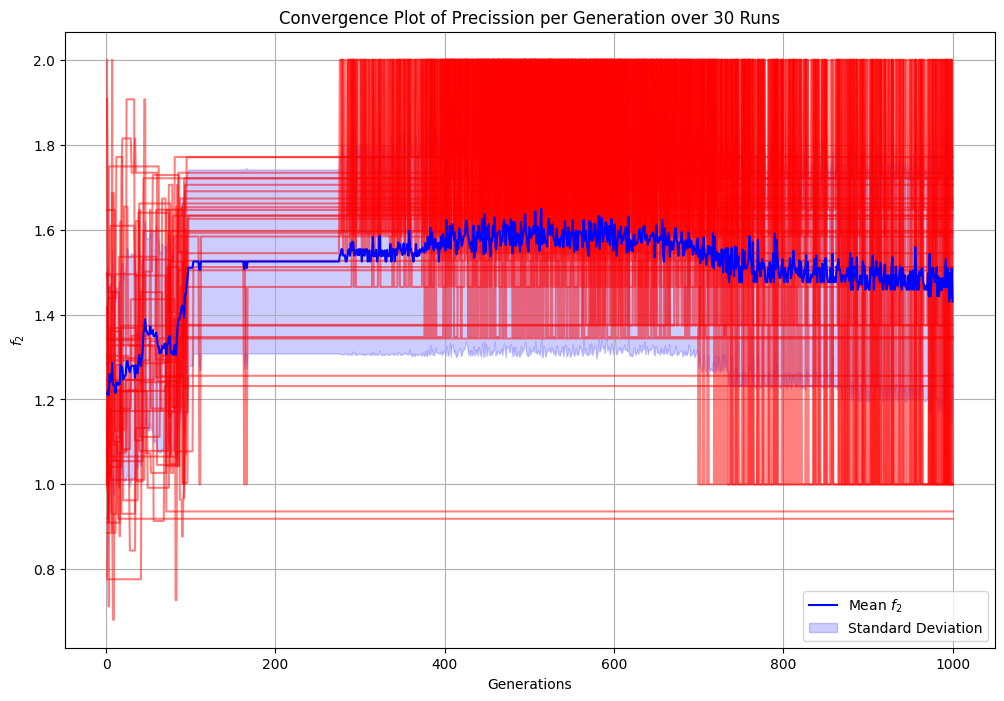

In [ ]:
# Determine the maximum number of generations across all runs
max_generations = max(len(fitness) for fitness in all_best_fitness)
generations = np.arange(1, max_generations + 1)

# Initialize a matrix to hold all fitness values, handling varying lengths
fitness_matrix = np.full((30, max_generations), np.nan)

# Separate objective values
all_best_fitness = np.array(all_best_fitness)
f1_all_runs = all_best_fitness[:, :, 0]  # All f1 values across runs and generations
f2_all_runs = all_best_fitness[:, :, 1]  # All f2 values across runs and generations

for i, best_fitness_per_gen in enumerate(f2_all_runs):
    fitness_length = len(best_fitness_per_gen)
    fitness_matrix[i, :fitness_length] = best_fitness_per_gen

# Plot all runs in red
plt.figure(figsize=(12, 8))
for i in range(30):
    plt.plot(
        generations,
        fitness_matrix[i],
        linestyle='-',
        color='red',
        alpha=0.5
    )

# Compute the mean and standard deviation across runs at each generation
mean_fitness_f2 = np.nanmean(fitness_matrix, axis=0)
std_fitness_f2 = np.nanstd(fitness_matrix, axis=0)

# Plot the mean best fitness
plt.plot(
    generations,
    mean_fitness_f2,
    linestyle='-',
    color='blue',
    label='Mean $f_2$'
)

# Fill the area between (mean - std) and (mean + std)
plt.fill_between(
    generations,
    mean_fitness_f2 - std_fitness_f2,
    mean_fitness_f2 + std_fitness_f2,
    color='blue',
    alpha=0.2,
    label='Standard Deviation'
)

plt.title('Convergence Plot of Precission per Generation over 30 Runs')
plt.xlabel('Generations')
plt.ylabel('$f_2$')
plt.legend()
plt.grid(True)
plt.show()

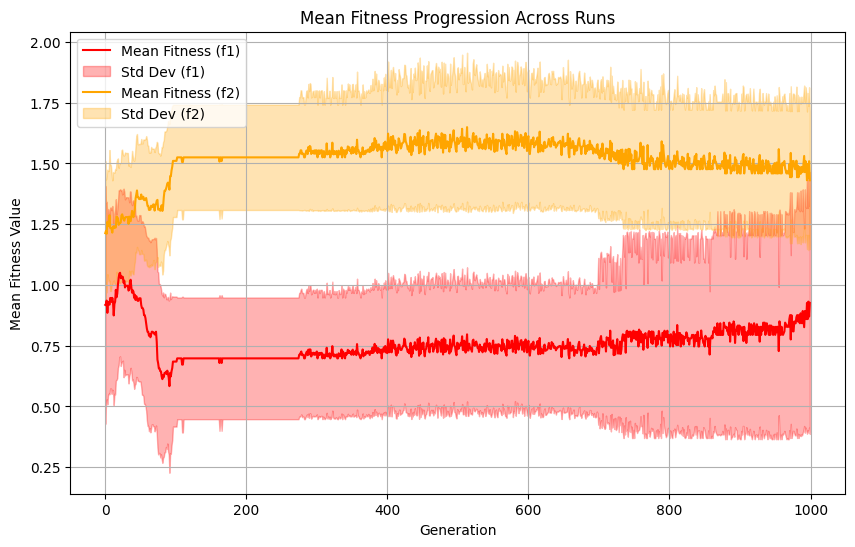

In [ ]:
# Plot 2: Mean Fitness Progression Across Runs (Both Objectives)
plt.figure(figsize=(10, 6))
plt.plot(mean_fitness_f1, label="Mean Fitness (f1)", color="red")
plt.fill_between(range(mean_fitness_f1.shape[0]), mean_fitness_f1 - std_fitness_f1, mean_fitness_f1 + std_fitness_f1, alpha=0.3, color='red', label="Std Dev (f1)")
plt.plot(mean_fitness_f2, label="Mean Fitness (f2)", color="orange")
plt.fill_between(range(mean_fitness_f2.shape[0]), mean_fitness_f2 - std_fitness_f2, mean_fitness_f2 + std_fitness_f2, alpha=0.3, color='orange', label="Std Dev (f2)")
plt.title("Mean Fitness Progression Across Runs")
plt.xlabel("Generation")
plt.ylabel("Mean Fitness Value")
plt.legend()
plt.grid()
plt.show()

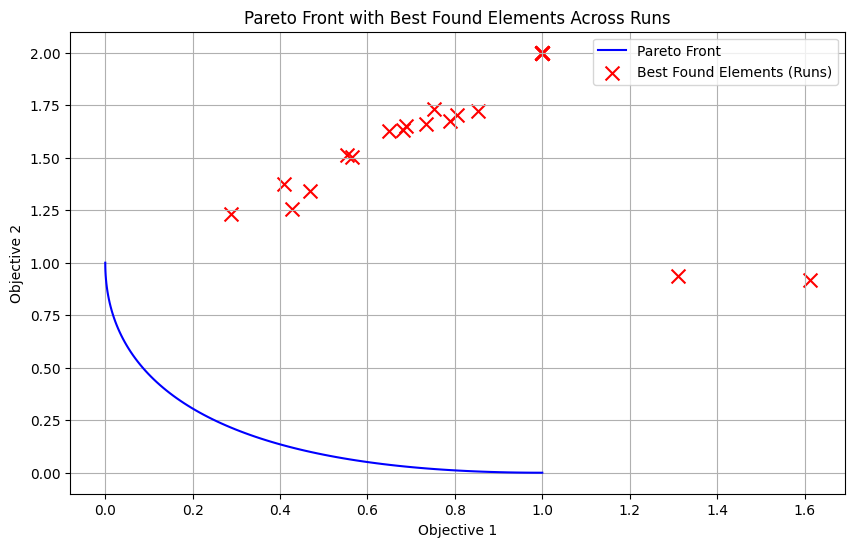

In [ ]:
# Plot 4: Pareto Front with Best Found Elements for Each Run

# Pareto front
best_elements = np.array([model[0]['fitness'] for model in best_models])  # Best models' fitness

plt.figure(figsize=(10, 6))
plt.plot(pareto_f1_vals, pareto_f2_vals, label="Pareto Front", color="blue")
plt.scatter(best_elements[:, 0], best_elements[:, 1], color="red", label="Best Found Elements (Runs)", marker="x", s=100)
plt.title("Pareto Front with Best Found Elements Across Runs")
plt.xlabel("Objective 1")
plt.ylabel("Objective 2")
plt.legend()
plt.grid()
plt.show()

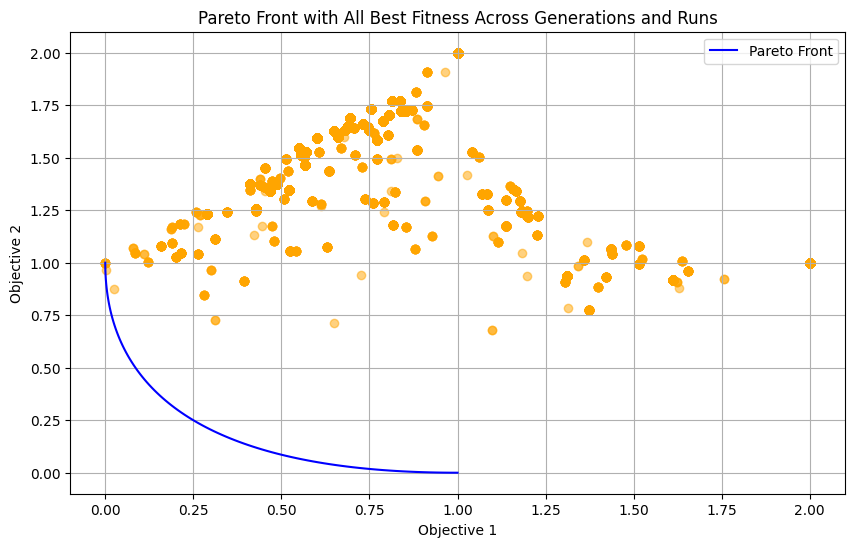

In [ ]:
# Plot 5: Pareto Front with All Best Fitness Values Across Generations for Each Run
plt.figure(figsize=(10, 6))
plt.plot(pareto_f1_vals, pareto_f2_vals, label="Pareto Front", color="blue")
for run in range(all_best_fitness.shape[0]):
    plt.scatter(f1_all_runs[run], f2_all_runs[run], color="orange", alpha=0.5)
plt.title("Pareto Front with All Best Fitness Across Generations and Runs")
plt.xlabel("Objective 1")
plt.ylabel("Objective 2")
plt.legend()
plt.grid()
plt.show()

# NAS

## Loading dependencies

In [ ]:
# Load surrogate model
model_path = 'drive/MyDrive/NAS/Israel/s_model/mlp_reg.pkl'

with open(model_path, 'rb') as file:
    model = pickle.load(file)

model

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MLPRegressor from version 1.3.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


MLPRegressor(activation='tanh', alpha=0.01, hidden_layer_sizes=(64, 64),
             max_iter=500, random_state=42)

In [ ]:
# Load scaler
scaler_path = 'drive/MyDrive/NAS/Israel/s_model/scaler.pkl'

with open(scaler_path, 'rb') as file:
    scaler = pickle.load(file)

scaler

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


StandardScaler()

## New misc functions

In [ ]:
def pop_gen(pop_size):
    """
    Generate a population using hyperlatin cube sampling to maximize representation of the search space.
    """
    # Define the parameter ranges
    n_head_choices = [4, 8, 12, 16, 32, 64]  # Number of attention heads
    n_embd_choices = [
        [n_head * i for i in range(2, 72)] for n_head in n_head_choices  # Embedding dimensions per n_head
    ]
    l_choices = [512, 1024]  # Sequence length
    n_layers_choices = [2, 4, 6, 12, 24, 48]  # Number of layers

    # Dimensions: n_head, n_embd, sequence_length, num_layers, residual_dropout, attention_dropout, activation_function
    sampler = qmc.LatinHypercube(d=7)  # 7 parameters
    samples = sampler.random(n=pop_size)  # Generate normalized samples in [0, 1]

    population = []
    for sample in samples:
        n_head_idx = int(sample[0] * len(n_head_choices))
        n_head = n_head_choices[n_head_idx]

        n_embd_idx = int(sample[1] * len(n_embd_choices[n_head_idx]))
        n_embd = n_embd_choices[n_head_idx][n_embd_idx]

        l_idx = int(sample[2] * len(l_choices))
        l = l_choices[l_idx]

        n_layers_idx = int(sample[3] * len(n_layers_choices))
        n_layers = n_layers_choices[n_layers_idx]

        residual_dropout = sample[4] * 0.3  # Scale to [0, 0.3]
        attention_dropout = sample[5] * 0.3  # Scale to [0, 0.3]

        # Use raw activation value between 0.0 and 1.0 for decoding later
        activation_value = sample[6]

        individual = [
            n_embd,      # Embedding dimension
            l,           # Sequence length
            n_layers,    # Number of layers
            n_head,      # Number of attention heads
            residual_dropout,  # Residual dropout
            attention_dropout,  # Attention dropout
            activation_value,   # Raw activation function value
        ]

        population.append({'individual': individual, 'fitness': 0})  # Fitness initialized to 0

    return population

In [ ]:
def network_decode(chromosome):
    # Extract individual from chromosome
    n_embd, sequence_length, n_layer, n_head, resid_pdrop, attn_pdrop, act_fn_value = chromosome

    # Map the activation function value to its corresponding function name
    activation_function_ranges = {
        (0.0, 0.2): "gelu",
        (0.2, 0.4): "relu",
        (0.4, 0.6): "tanh",
        (0.6, 0.8): "swish",
        (0.8, 1.0): "sigmoid"
    }

    # Decode activation function based on mapping
    for (low, high), func_name in activation_function_ranges.items():
        if low <= act_fn_value < high:
            activation_function = func_name
            break

    print(f'Activation function is {activation_function}')

    # Calculate derived parameters
    n_inner = 4 * int(n_embd)  # Explicitly cast to Python int

    # Explicitly cast all variables to Python types
    config = GPT2Config(
        vocab_size=int(50257),                   # Default GPT-2 vocabulary size
        n_positions=int(sequence_length),        # Sequence length
        n_ctx=int(sequence_length),              # Context length (same as sequence length)
        n_embd=int(n_embd),                      # Embedding dimension
        n_layer=int(n_layer),                    # Number of layers
        n_head=int(n_head),                      # Number of attention heads
        n_inner=int(n_inner),                    # Feedforward dimension
        resid_pdrop=float(resid_pdrop),          # Residual dropout
        attn_pdrop=float(attn_pdrop),            # Attention dropout
        activation_function=str(activation_function)  # Activation function
    )

    # Instantiate the model
    try:
        model = GPT2LMHeadModel(config)
    except Exception as e:
        print("Error during model creation:")
        print(e)
        raise

    return model

## Objective function

### Surrogate model for predicting meteor score

In [ ]:
def estimate_meteor(chromosome):
  # Ensure chromosome is NumPy array before reshaping
  if isinstance(chromosome, torch.Tensor):
    chromosome = chromosome.cpu().numpy()

  x = pd.DataFrame(np.array(chromosome).reshape(1, -1), columns=scaler.feature_names_in_)
  scaled_individual = scaler.transform(x)
  return model.predict(scaled_individual)[0]

In [ ]:
ind = pop_gen(1)

score = estimate_meteor(ind[0]['individual'])
score

np.float64(0.3710641919673762)

### Parameter count

In [ ]:
def count_distilgpt2_params(chromosome, vocab_size=50257):
    """
    Estimates parameter count for a DistilGPT2 model given its architecture encoding.
    encoding: [e, p, t, c]  # Embedding dim, sequence length, num transformer layers, num cell pairs per layer
    """
    e, l, n, *rest = chromosome  # Extract parameters

    # Embedding layers
    token_emb = vocab_size * e
    pos_emb = l * e

    # Transformer layers (self-attention + feedforward + LayerNorm)
    transformer_params = n * (12 * e**2 + 2 * e)

    # Total parameter count
    total_params = token_emb + pos_emb + transformer_params
    return total_params

In [ ]:
chromosome = pop_gen(pop_size=1)[0]
print(f'Chromosome is {chromosome}')

params = count_distilgpt2_params(chromosome['individual'])

print(f'Estimated params: {params}')

Chromosome is {'individual': [80, 1024, 4, 4, np.float64(0.1236667966479535), np.float64(0.2699567313741721), np.float64(0.01943675459864036)], 'fitness': 0}
Estimated params: 4410320


## Search process

### Misc

In [ ]:
def get_valid_e(h):
    """Returns the valid embedding dimensions for a given h."""
    return [h * i for i in range(2, 72)]

def get_valid_h():
    """Returns the valid number of attention heads."""
    return [4, 8, 12, 16, 32, 64]

def get_valid_n():
    """Returns the valid number of Transformer units."""
    return [2, 4, 6, 12, 24, 48]

def get_valid_l():
    """Returns the valid sequence lengths."""
    return [512, 1024]

def get_valid_r_a():
    """Returns the valid dropout rates (both residual and attention)."""
    return (0.0, 0.3)  # Continuous range

def get_valid_g():
    """Returns the valid range for activation function encoding."""
    return (0.0, 1.0)  # Continuous range

def clip_to_nearest(value, valid_values):
    """Clips a value to the nearest valid discrete value."""
    return min(valid_values, key=lambda x: abs(x - value))

def clip_to_range(value, value_range):
    """Clips a continuous value within a min-max range."""
    return max(value_range[0], min(value, value_range[1]))

def repair_architecture(individual):
    """
    Repair function to clip each allele to its valid range.
    """
    repaired = individual.copy()  # Copy to avoid modifying original

    # Extract values from individual
    e, l, n, h, r, a, g = repaired

    # Clip h first since e depends on it
    h = clip_to_nearest(h, get_valid_h())

    # Clip e based on h
    valid_e = get_valid_e(h)
    e = clip_to_nearest(e, valid_e)

    # Clip other discrete values
    l = clip_to_nearest(l, get_valid_l())
    n = clip_to_nearest(n, get_valid_n())

    # Clip continuous values (r, a, g)
    r = clip_to_range(r, get_valid_r_a())
    a = clip_to_range(a, get_valid_r_a())
    g = clip_to_range(g, get_valid_g())

    # Return repaired individual
    return [e, l, n, h, r, a, g]

In [ ]:
# Example individual with some out-of-range values
test_individual = [500, 700, 10, 20, 0.5, -0.1, 1.2]  # Invalid values

# Apply repair function
repaired_individual = repair_architecture(test_individual)

print("Original:", test_individual)
print("Repaired:", repaired_individual)

Original: [500, 700, 10, 20, 0.5, -0.1, 1.2]
Repaired: [496, 512, 12, 16, 0.3, 0.0, 1.0]


In [ ]:
torch.cuda.empty_cache()
gc.collect()

77

### Config 1

In [ ]:
for i in range(1):
  print(f'\nRunning experiment for gif creation')

  best_element, _, _, gens_dict = sms_modes(
      [count_distilgpt2_params, estimate_meteor],
      [(8, 4544), (512, 1024), (2, 48), (4, 64), (0.0, 0.3), (0.0, 0.3), (0.0, 1.0)],
      repair_architecture,
      n_var=7,
      n_obj=2,
      nas=True,
      save_progress=True,
  )

  print("The best individual is", best_element)


Running experiment for gif creation
Using device: cpu


Generations: 100%|██████████| 100/100 [00:54<00:00,  1.84it/s]

The best individual is [{'individual': [32, 512, 48, 16, 0.0, 0.0, 0.0], 'fitness': [np.float32(2217504.0), np.float64(0.6539055431408776)]}]


In [ ]:
create_gif("drive/MyDrive/NAS/Israel/config_1", gens_dict)

🔥 Animation saved as pareto_evolution.gif
📊 Hypervolume plot saved.


In [ ]:
best_models = []
all_best_fitness = []
F_arr = []

for i in range(30):
  print(f'\nRunning experiment {i + 1}')

  best_element, best_fitness_per_gen, Fs, _ = sms_modes(
      [count_distilgpt2_params, estimate_meteor],
      [(8, 4544), (512, 1024), (2, 48), (4, 64), (0.0, 0.3), (0.0, 0.3), (0.0, 1.0)],
      repair_architecture,
      n_var=7,
      n_obj=2,
      nas=True
  )

  print("The best individual is", best_element)

  F_arr.append(Fs)
  best_models.append(best_element[0])
  all_best_fitness.append(best_fitness_per_gen)


Running experiment 1
Using device: cpu


Generations: 100%|██████████| 100/100 [01:04<00:00,  1.56it/s]

The best individual is [{'individual': [128, 512, 24, 64, 0.0, np.float32(0.3), np.float32(1.0)], 'fitness': [np.float32(11223168.0), np.float64(0.6730450255442135)]}]

Running experiment 2
Using device: cpu



Generations: 100%|██████████| 100/100 [01:04<00:00,  1.55it/s]

The best individual is [{'individual': [128, 512, 2, 64, 0.0, np.float32(0.3), np.float32(0.39624166)], 'fitness': [np.float32(6892160.0), np.float64(0.5817749668910943)]}]

Running experiment 3
Using device: cpu


...

The best individual is [{'individual': [128, 512, 48, 64, 0.0, 0.3, np.float32(0.16477752)], 'fitness': [np.float32(15947904.0), np.float64(0.8761056944253629)]}]

Running experiment 29
Using device: cpu



Generations: 100%|██████████| 100/100 [01:01<00:00,  1.64it/s]

The best individual is [{'individual': [8, 512, 48, 4, 0.0, 0.0, 0.0], 'fitness': [np.float32(443784.0), np.float64(0.6731438679827262)]}]

Running experiment 30
Using device: cpu



Generations: 100%|██████████| 100/100 [01:00<00:00,  1.65it/s]

The best individual is [{'individual': [8, 512, 48, 4, 0.0, 0.0, 0.0], 'fitness': [np.float32(443784.0), np.float64(0.6731438679827262)]}]


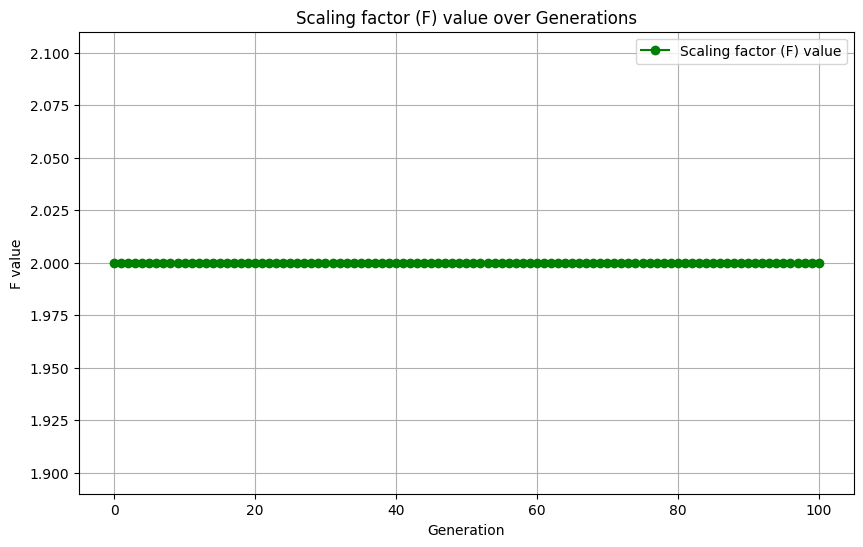

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(F_arr[0], label="Scaling factor (F) value", color="green", marker='o')
plt.title("Scaling factor (F) value over Generations")
plt.xlabel("Generation")
plt.ylabel("F value")
plt.legend()
plt.grid()
plt.show()

In [ ]:
selected_gens = [5, 10, 15, 20, 25, 30]
param_count_vals = {gen: [] for gen in selected_gens}
meteor_vals = {gen: [] for gen in selected_gens}

# Extract param count and meteor vals for each selected generation
for exp in all_best_fitness:
  for gen in selected_gens:
    param_count_vals[gen].append(exp[gen - 1][0])
    meteor_vals[gen].append(exp[gen - 1][1])

# Convert to lists for sns
param_count_data = [param_count_vals[gen] for gen in selected_gens]
meteor_data = [meteor_vals[gen] for gen in selected_gens]

# Compute medians for overlaying trend lines
param_count_medians = [np.median(param_count_vals[gen]) for gen in selected_gens]
meteor_medians = [np.median(meteor_vals[gen]) for gen in selected_gens]

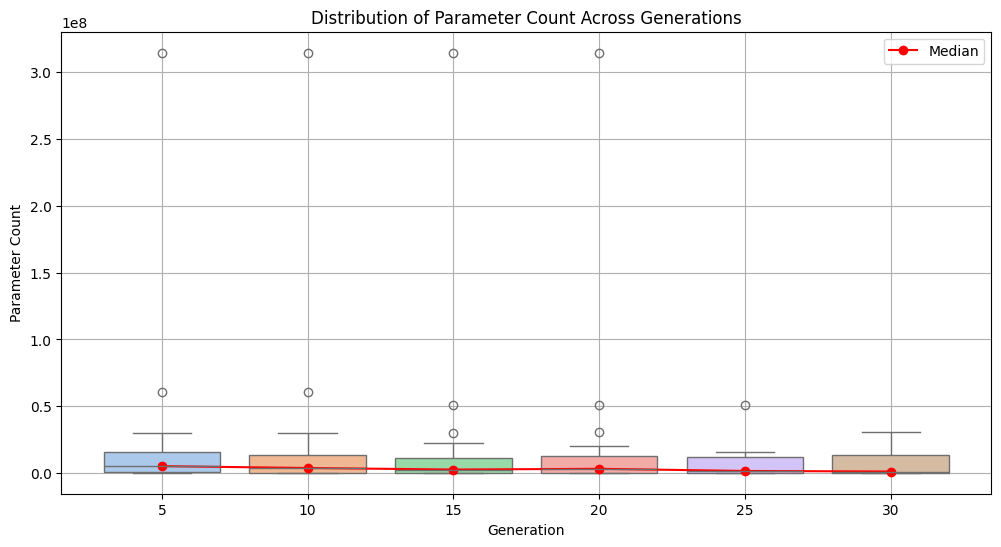

In [ ]:
# Plot for Parameter Count Objective
plt.figure(figsize=(12, 6))
sns.boxplot(data=param_count_data, palette="pastel")
plt.plot(range(len(selected_gens)), param_count_medians, marker='o', linestyle='-', color='red', label='Median')
plt.xticks(range(len(selected_gens)), selected_gens)
plt.title('Distribution of Parameter Count Across Generations')
plt.xlabel('Generation')
plt.ylabel('Parameter Count')
plt.legend()
plt.grid(True)
plt.show()

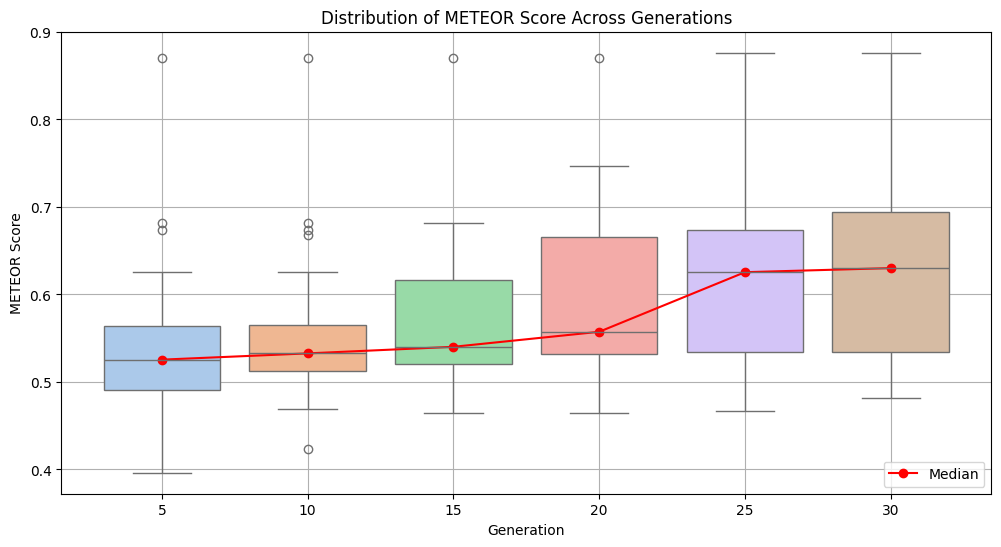

In [ ]:
# Plot for METEOR Score Objective
plt.figure(figsize=(12, 6))
sns.boxplot(data=meteor_data, palette="pastel")
plt.plot(range(len(selected_gens)), meteor_medians, marker='o', linestyle='-', color='red', label='Median')
plt.xticks(range(len(selected_gens)), selected_gens)
plt.title('Distribution of METEOR Score Across Generations')
plt.xlabel('Generation')
plt.ylabel('METEOR Score')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Determine the maximum number of generations
max_generations = max(len(fitness) for fitness in all_best_fitness)
generations = range(1, max_generations + 1)


# Initialize lists to store mean and std of param counts and meteor scores
mean_param_counts = []
std_param_counts = []
mean_meteor_scores = []
std_meteor_scores = []

# Calculate means and stds for each generation across experiments
for gen in generations:
    param_counts = [exp[gen - 1][0] for exp in all_best_fitness if gen <= len(exp)]
    meteor_scores = [exp[gen - 1][1] for exp in all_best_fitness if gen <= len(exp)]

    mean_param_counts.append(np.mean(param_counts))
    std_param_counts.append(np.std(param_counts))

    mean_meteor_scores.append(np.mean(meteor_scores))
    std_meteor_scores.append(np.std(meteor_scores))

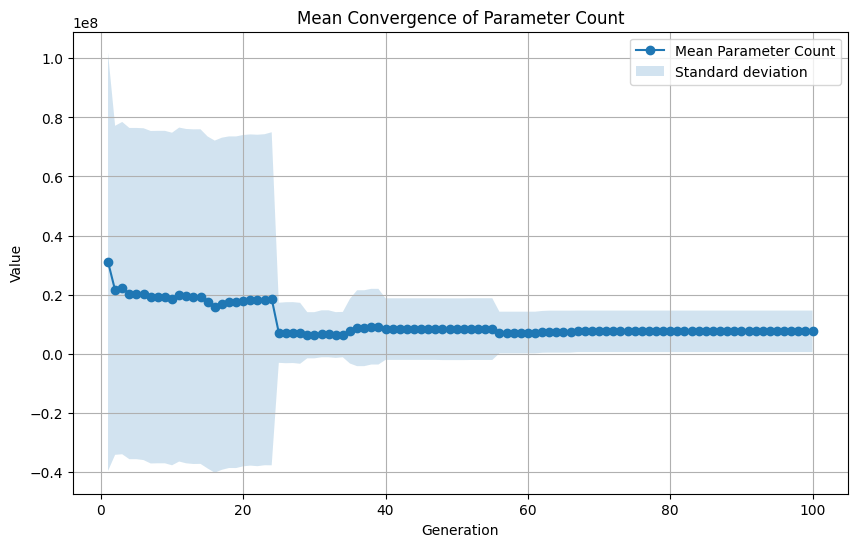

In [ ]:
# Plot mean param count
plt.figure(figsize=(10, 6))
plt.plot(generations, mean_param_counts, label='Mean Parameter Count', marker='o')
plt.fill_between(generations, np.array(mean_param_counts) - np.array(std_param_counts),
                 np.array(mean_param_counts) + np.array(std_param_counts), alpha=0.2, label='Standard deviation')
plt.xlabel('Generation')
plt.ylabel('Value')
plt.title('Mean Convergence of Parameter Count')
plt.legend()
plt.grid(True)
plt.show()

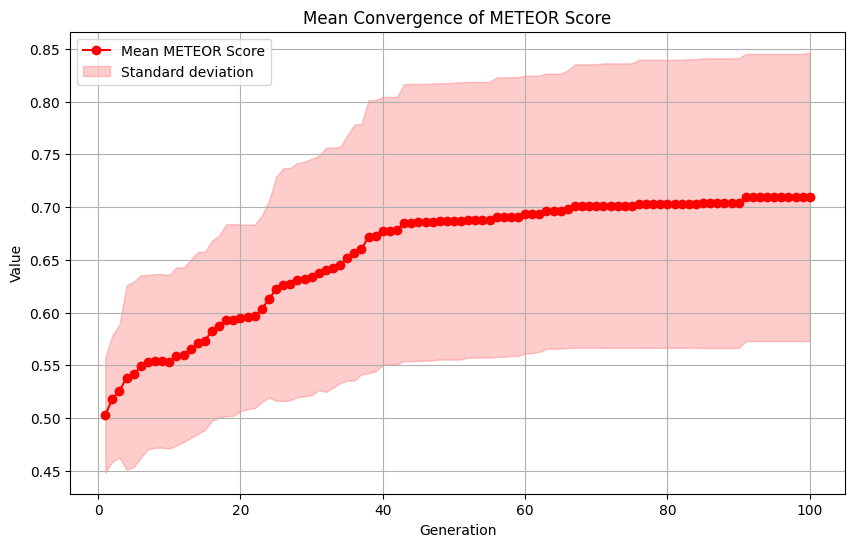

In [ ]:
# Plot mean METEOR score
plt.figure(figsize=(10, 6))
plt.plot(generations, mean_meteor_scores, label='Mean METEOR Score', marker='o', color='red')
plt.fill_between(generations, np.array(mean_meteor_scores) - np.array(std_meteor_scores),
                 np.array(mean_meteor_scores) + np.array(std_meteor_scores), alpha=0.2, label='Standard deviation', color='red')
plt.xlabel('Generation')
plt.ylabel('Value')
plt.title('Mean Convergence of METEOR Score')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
reference_point = calculate_reference_point(best_models, ["min", "max"])
best_model = select_best_individuals(best_models, ["min", "max"], reference_point, 1)
print(f'Best model is: {best_model}')

Best model is: [{'individual': [8, 512, 48, 4, 0.0, 0.0, 0.0], 'fitness': [np.float32(443784.0), np.float64(0.6731438679827262)]}]


In [ ]:
# Decode the individual into a PyTorch model
best_model_decoded = network_decode(best_model[0]['individual'])


# Export the model to a .pkl file in Google Drive
drive_path = '/content/drive/MyDrive/NAS/Israel/config_1/best_model.pkl'

with open(drive_path, 'wb') as f:
    pickle.dump(best_model_decoded, f)

print(f"Best model saved to: {drive_path}")


Activation function is gelu
Best model saved to: /content/drive/MyDrive/NAS/Israel/config_1/best_model.pkl


### Config 2

In [ ]:
for i in range(1):
  print(f'\nRunning experiment for gif creation')

  best_element, _, _, gens_dict = sms_modes(
      [count_distilgpt2_params, estimate_meteor],
      [(8, 4544), (512, 1024), (2, 48), (4, 64), (0.0, 0.3), (0.0, 0.3), (0.0, 1.0)],
      repair_architecture,
      n_var=7,
      n_obj=2,
      gens=100,
      mu=100,
      F=0.5,
      auto_adapt=True,
      nas=True,
      save_progress=True,
  )

  print("The best individual is", best_element)


Running experiment for gif creation
Using device: cpu


Generations: 100%|██████████| 100/100 [01:21<00:00,  1.22it/s]

The best individual is [{'individual': [8, 512, 48, 4, 0.0, 0.0, 0.0], 'fitness': [np.float32(443784.0), np.float64(0.6731438679827262)]}]


In [ ]:
create_gif("drive/MyDrive/NAS/Israel/config_2", gens_dict)

🔥 Animation saved as pareto_evolution.gif
📊 Hypervolume plot saved.


In [ ]:
best_models = []
all_best_fitness = []
F_arr = []

for i in range(30):
  print(f'\nRunning experiment {i + 1}')

  best_element, best_fitness_per_gen, Fs, _ = sms_modes(
      [count_distilgpt2_params, estimate_meteor],
      [(8, 4544), (512, 1024), (2, 48), (4, 64), (0.0, 0.3), (0.0, 0.3), (0.0, 1.0)],
      repair_architecture,
      n_var=7,
      n_obj=2,
      gens=100,
      mu=100,
      F=0.5,
      auto_adapt=True,
      nas=True
  )

  print("The best individual is", best_element)

  F_arr.append(Fs)
  best_models.append(best_element[0])
  all_best_fitness.append(best_fitness_per_gen)


Running experiment 1
Using device: cpu


Generations: 100%|██████████| 100/100 [01:21<00:00,  1.23it/s]

The best individual is [{'individual': [64, 512, 48, 32, 0.0, np.float32(0.16335975), np.float32(0.31602865)], 'fitness': [np.float32(5614656.0), np.float64(0.6425275908375057)]}]

Running experiment 2
Using device: cpu



Generations: 100%|██████████| 100/100 [01:20<00:00,  1.24it/s]

The best individual is [{'individual': [320, 512, 48, 64, np.float32(0.10242781), 0.3, np.float32(0.7806347)], 'fitness': [np.float32(75259200.0), np.float64(0.7663303232088128)]}]

Running experiment 3
Using device: cpu


...

The best individual is [{'individual': [128, 512, 48, 64, np.float32(0.12579127), np.float64(0.2473511982626502), 1.0], 'fitness': [np.float32(15947904.0), np.float64(0.6624654746041256)]}]

Running experiment 29
Using device: cpu



Generations: 100%|██████████| 100/100 [01:21<00:00,  1.23it/s]

The best individual is [{'individual': [8, 512, 48, 4, 0.0, 0.0, 0.0], 'fitness': [np.float32(443784.0), np.float64(0.6731438679827262)]}]

Running experiment 30
Using device: cpu



Generations: 100%|██████████| 100/100 [01:22<00:00,  1.21it/s]

The best individual is [{'individual': [8, 512, 48, 4, 0.0, 0.0, 0.0], 'fitness': [np.float32(443784.0), np.float64(0.6731438679827262)]}]


In [ ]:
# Determine the maximum number of generations
max_generations = max(len(fitness) for fitness in all_best_fitness)
generations = range(1, max_generations + 1)


# Initialize lists to store mean and std of F
mean_F = []
std_F = []

# Calculate means and stds for each generation across experiments
for gen in generations:
    F = [exp[gen - 1] for exp in F_arr if gen <= len(exp)]

    mean_F.append(np.mean(F))
    std_F.append(np.std(F))

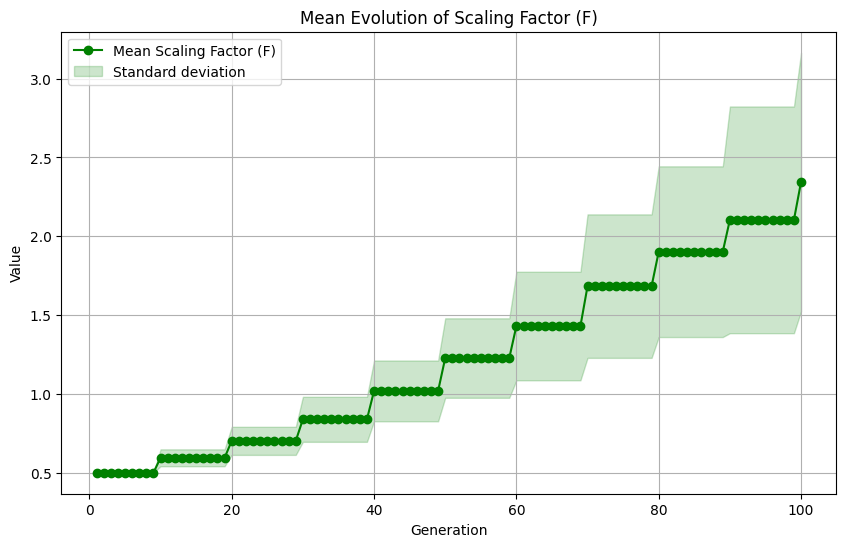

In [ ]:
# Plot mean F evolution
plt.figure(figsize=(10, 6))
plt.plot(generations, mean_F, label='Mean Scaling Factor (F)', marker='o', color='green')
plt.fill_between(generations, np.array(mean_F) - np.array(std_F),
                 np.array(mean_F) + np.array(std_F), alpha=0.2, label='Standard deviation', color='green')
plt.xlabel('Generation')
plt.ylabel('Value')
plt.title('Mean Evolution of Scaling Factor (F)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
selected_gens = [5, 10, 15, 20, 25, 30]
param_count_vals = {gen: [] for gen in selected_gens}
meteor_vals = {gen: [] for gen in selected_gens}

# Extract param count and meteor vals for each selected generation
for exp in all_best_fitness:
  for gen in selected_gens:
    param_count_vals[gen].append(exp[gen - 1][0])
    meteor_vals[gen].append(exp[gen - 1][1])

# Convert to lists for sns
param_count_data = [param_count_vals[gen] for gen in selected_gens]
meteor_data = [meteor_vals[gen] for gen in selected_gens]

# Compute medians for overlaying trend lines
param_count_medians = [np.median(param_count_vals[gen]) for gen in selected_gens]
meteor_medians = [np.median(meteor_vals[gen]) for gen in selected_gens]

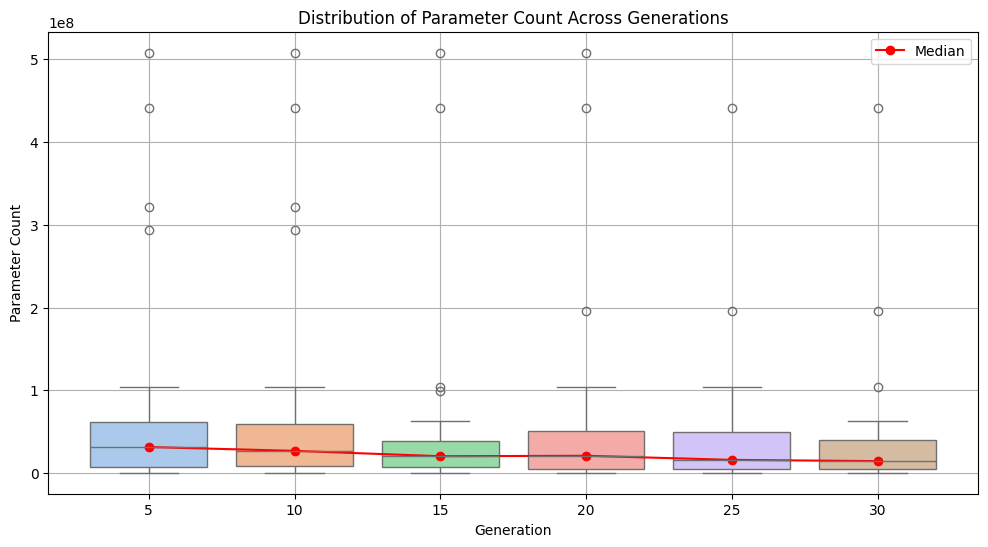

In [ ]:
# Plot for Parameter Count Objective
plt.figure(figsize=(12, 6))
sns.boxplot(data=param_count_data, palette="pastel")
plt.plot(range(len(selected_gens)), param_count_medians, marker='o', linestyle='-', color='red', label='Median')
plt.xticks(range(len(selected_gens)), selected_gens)
plt.title('Distribution of Parameter Count Across Generations')
plt.xlabel('Generation')
plt.ylabel('Parameter Count')
plt.legend()
plt.grid(True)
plt.show()

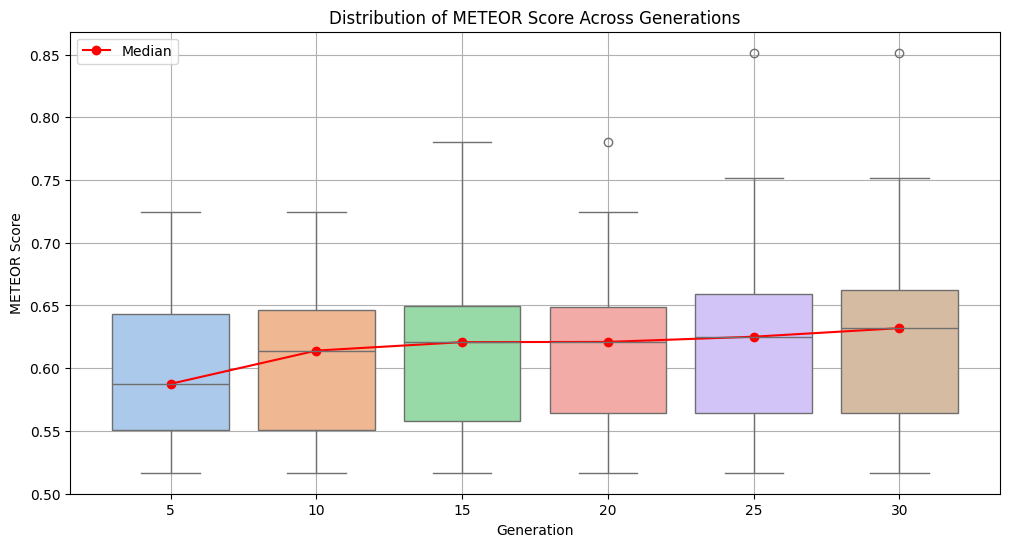

In [ ]:
# Plot for METEOR Score Objective
plt.figure(figsize=(12, 6))
sns.boxplot(data=meteor_data, palette="pastel")
plt.plot(range(len(selected_gens)), meteor_medians, marker='o', linestyle='-', color='red', label='Median')
plt.xticks(range(len(selected_gens)), selected_gens)
plt.title('Distribution of METEOR Score Across Generations')
plt.xlabel('Generation')
plt.ylabel('METEOR Score')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Determine the maximum number of generations
max_generations = max(len(fitness) for fitness in all_best_fitness)
generations = range(1, max_generations + 1)


# Initialize lists to store mean and std of param counts and meteor scores
mean_param_counts = []
std_param_counts = []
mean_meteor_scores = []
std_meteor_scores = []

# Calculate means and stds for each generation across experiments
for gen in generations:
    param_counts = [exp[gen - 1][0] for exp in all_best_fitness if gen <= len(exp)]
    meteor_scores = [exp[gen - 1][1] for exp in all_best_fitness if gen <= len(exp)]

    mean_param_counts.append(np.mean(param_counts))
    std_param_counts.append(np.std(param_counts))

    mean_meteor_scores.append(np.mean(meteor_scores))
    std_meteor_scores.append(np.std(meteor_scores))

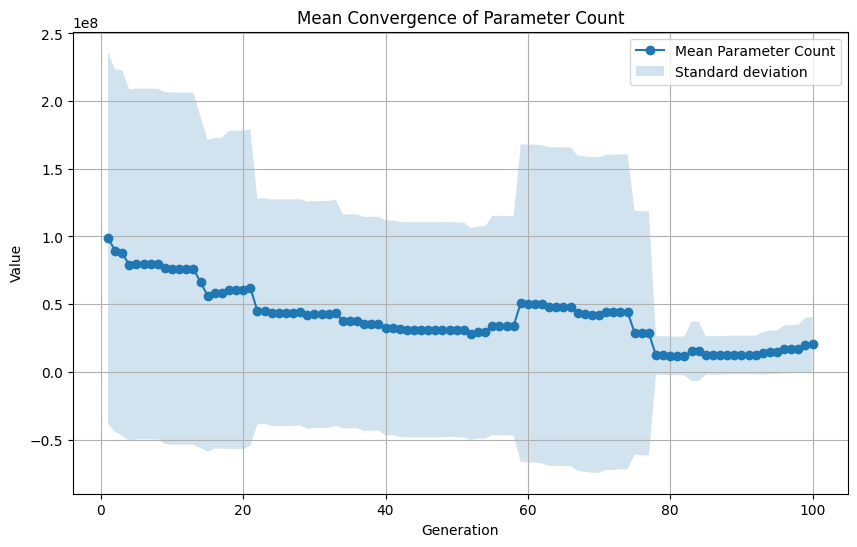

In [ ]:
# Plot mean param count
plt.figure(figsize=(10, 6))
plt.plot(generations, mean_param_counts, label='Mean Parameter Count', marker='o')
plt.fill_between(generations, np.array(mean_param_counts) - np.array(std_param_counts),
                 np.array(mean_param_counts) + np.array(std_param_counts), alpha=0.2, label='Standard deviation')
plt.xlabel('Generation')
plt.ylabel('Value')
plt.title('Mean Convergence of Parameter Count')
plt.legend()
plt.grid(True)
plt.show()

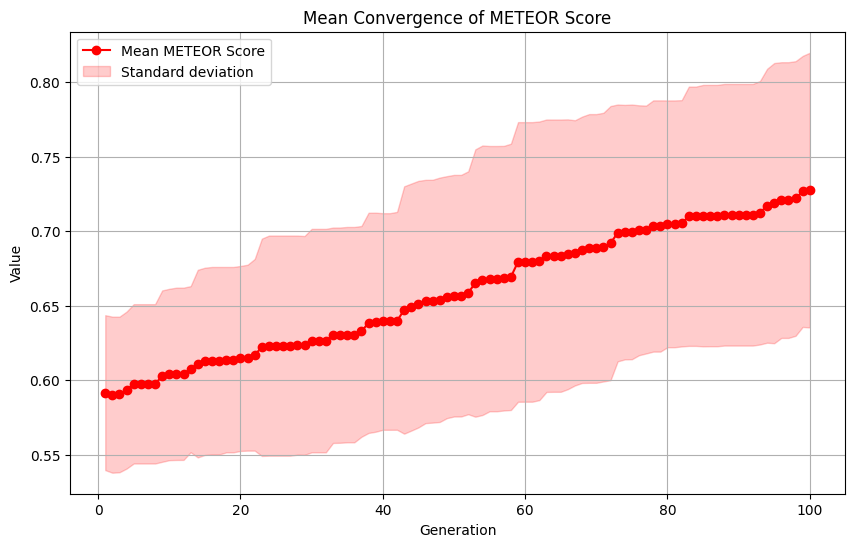

In [ ]:
# Plot mean METEOR score
plt.figure(figsize=(10, 6))
plt.plot(generations, mean_meteor_scores, label='Mean METEOR Score', marker='o', color='red')
plt.fill_between(generations, np.array(mean_meteor_scores) - np.array(std_meteor_scores),
                 np.array(mean_meteor_scores) + np.array(std_meteor_scores), alpha=0.2, label='Standard deviation', color='red')
plt.xlabel('Generation')
plt.ylabel('Value')
plt.title('Mean Convergence of METEOR Score')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
reference_point = calculate_reference_point(best_models, ["min", "max"])
best_model = select_best_individuals(best_models, ["min", "max"], reference_point, 1)

print(f'Best model is: {best_model}')

Best model is: [{'individual': [8, 512, 48, 4, 0.0, 0.0, 0.0], 'fitness': [np.float32(443784.0), np.float64(0.6731438679827262)]}]


In [ ]:
# Decode the individual into a PyTorch model
best_model_decoded = network_decode(best_model[0]['individual'])


# Export the model to a .pkl file in Google Drive
drive_path = '/content/drive/MyDrive/NAS/Israel/config_2/best_model.pkl'

with open(drive_path, 'wb') as f:
    pickle.dump(best_model_decoded, f)

print(f"Best model saved to: {drive_path}")

Activation function is gelu
Best model saved to: /content/drive/MyDrive/NAS/Israel/config_2/best_model.pkl


### Config 3

In [ ]:
for i in range(1):
  print(f'\nRunning experiment for gif creation')

  best_element, _, _, gens_dict = sms_modes(
      [count_distilgpt2_params, estimate_meteor],
      [(8, 4544), (512, 1024), (2, 48), (4, 64), (0.0, 0.3), (0.0, 0.3), (0.0, 1.0)],
      repair_architecture,
      n_var=7,
      n_obj=2,
      gens=500,
      mu=200,
      F=0.5,
      auto_adapt=True,
      nas=True,
      save_progress=True
  )

  print("The best individual is", best_element)


Running experiment for gif creation
Using device: cpu


Generations: 100%|██████████| 500/500 [11:50<00:00,  1.42s/it]

The best individual is [{'individual': [128, 512, 48, 64, 0.0, 0.3, 0.0], 'fitness': [np.float32(15947904.0), np.float64(0.8691268725584407)]}]


In [ ]:
create_gif("drive/MyDrive/NAS/Israel/config_3", gens_dict)

🔥 Animation saved as pareto_evolution.gif
📊 Hypervolume plot saved.


In [ ]:
best_models_path = "drive/MyDrive/NAS/Israel/config_3/best_models.pkl"
all_best_fitness_path = "drive/MyDrive/NAS/Israel/config_3/all_best_fitness.pkl"
F_arr_path = "drive/MyDrive/NAS/Israel/config_3/F_arr.pkl"

In [ ]:
for i in range(20):
  print(f'\nRunning experiment {i + 1}')

  best_element, best_fitness_per_gen, Fs, _ = sms_modes(
      [count_distilgpt2_params, estimate_meteor],
      [(8, 4544), (512, 1024), (2, 48), (4, 64), (0.0, 0.3), (0.0, 0.3), (0.0, 1.0)],
      repair_architecture,
      n_var=7,
      n_obj=2,
      gens=250,
      mu=200,
      F=0.5,
      auto_adapt=True,
      nas=True,
      early_conv=True
  )

  print("The best individual is", best_element)

  with open(best_models_path, 'ab') as f:
    pickle.dump(best_element[0], f)

  with open(all_best_fitness_path, 'ab') as f:
    pickle.dump(best_fitness_per_gen, f)

  with open(F_arr_path, 'ab') as f:
    pickle.dump(Fs, f)


Running experiment 1
Using device: cpu


Generations:   0%|          | 1/250 [00:01<06:06,  1.47s/it]

(0.7) <= 0.6565052793767195 <= (1.0)


Generations:  20%|██        | 51/250 [01:20<05:31,  1.67s/it]

(0.7) <= 0.6711639275513539 <= (1.0)


...

(0.7) <= 0.6588362512811137 <= (1.0)


Generations:  40%|████      | 101/250 [02:35<03:36,  1.45s/it]

(0.7) <= 0.6588362512811137 <= (1.0)


Generations:  60%|██████    | 150/250 [03:53<02:35,  1.56s/it]

(0.7) <= 0.7962873620009784 <= (1.0)
Convergence reached, stopping early
The best individual is [{'individual': [192, 512, 48, 64, np.float32(0.08126724), np.float32(0.27787605), 0.0], 'fitness': [np.float32(30999744.0), np.float64(0.7962873620009784)]}]


In [ ]:
best_models = []
all_best_fitness = []
F_arr = []

with open(best_models_path, 'rb') as f:
  while True:
    try:
      mod = pickle.load(f)
      best_models.append(mod)
    except EOFError:
      break

with open(all_best_fitness_path, 'rb') as f:
  while True:
    try:
      fit = pickle.load(f)
      all_best_fitness.append(fit)
    except EOFError:
      break

with open(F_arr_path, 'rb') as f:
  while True:
    try:
      F = pickle.load(f)
      F_arr.append(F)
    except EOFError:
      break

print(best_models)
print(all_best_fitness)
print(F_arr)

[{'individual': [128, 512, 48, 64, 0.0, 0.3, 1.0], 'fitness': [np.float32(15947904.0), np.float64(0.7804862203146757)]}, {'individual': [128, 512, 48, 64, 0.0, 0.3, 0.0], 'fitness': [np.float32(15947904.0), np.float64(0.8691268725584407)]}, {'individual': [8, 512, 48, 4, 0.0, 0.0, 0.0], 'fitness': [np.float32(443784.0), np.float64(0.6731438679827262)]}, {'individual': [128, 512, 48, 64, 0.0, np.float64(0.1955818593384012), np.float64(0.40182616817932443)], 'fitness': [np.float32(15947904.0), np.float64(0.7196694872210658)]}, {'individual': [128, 512, 48, 64, 0.0, np.float32(0.27994868), np.float32(0.42734092)], 'fitness': [np.float32(15947904.0), np.float64(0.8456250175789102)]}, {'individual': [284, 512, 48, 4, 0.0, 0.0, 0.0], 'fitness': [np.float32(60903516.0), np.float64(0.6811790487313414)]}, {'individual': [128, 512, 48, 64, 0.0, 0.3, 1.0], 'fitness': [np.float32(15947904.0), np.float64(0.7804862203146757)]}, {'individual': [64, 512, 48, 32, 0.0, 0.3, np.float32(0.29281026)], 'fit

In [ ]:
# Determine the maximum number of generations
max_generations = max(len(fitness) for fitness in all_best_fitness)
generations = range(1, max_generations + 1)


# Initialize lists to store mean and std of F
mean_F = []
std_F = []

# Calculate means and stds for each generation across experiments
for gen in generations:
    F = [exp[gen - 1] for exp in F_arr if gen <= len(exp)]

    mean_F.append(np.mean(F))
    std_F.append(np.std(F))

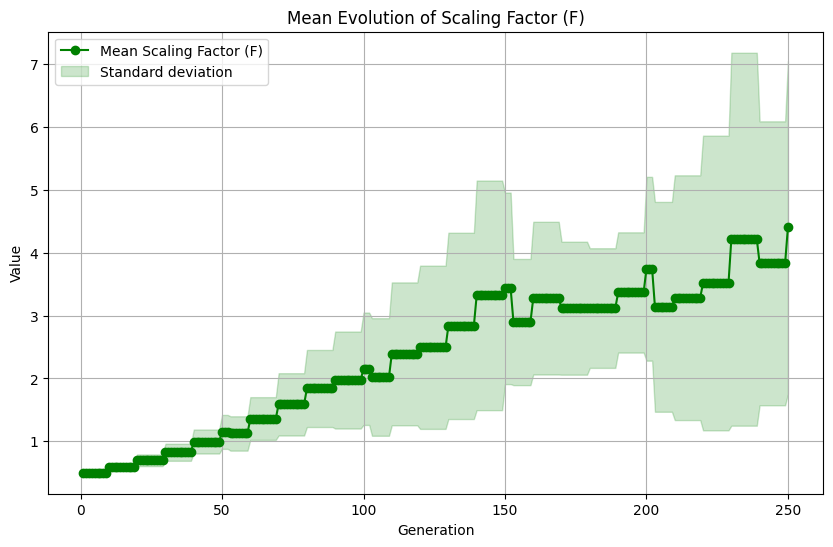

In [ ]:
# Plot mean F evolution
plt.figure(figsize=(10, 6))
plt.plot(generations, mean_F, label='Mean Scaling Factor (F)', marker='o', color='green')
plt.fill_between(generations, np.array(mean_F) - np.array(std_F),
                 np.array(mean_F) + np.array(std_F), alpha=0.2, label='Standard deviation', color='green')
plt.xlabel('Generation')
plt.ylabel('Value')
plt.title('Mean Evolution of Scaling Factor (F)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
selected_gens = [5, 10, 15, 20, 25, 30]
param_count_vals = {gen: [] for gen in selected_gens}
meteor_vals = {gen: [] for gen in selected_gens}

# Extract param count and meteor vals for each selected generation
for exp in all_best_fitness:
  for gen in selected_gens:
    param_count_vals[gen].append(exp[gen - 1][0])
    meteor_vals[gen].append(exp[gen - 1][1])

# Convert to lists for sns
param_count_data = [param_count_vals[gen] for gen in selected_gens]
meteor_data = [meteor_vals[gen] for gen in selected_gens]

# Compute medians for overlaying trend lines
param_count_medians = [np.median(param_count_vals[gen]) for gen in selected_gens]
meteor_medians = [np.median(meteor_vals[gen]) for gen in selected_gens]

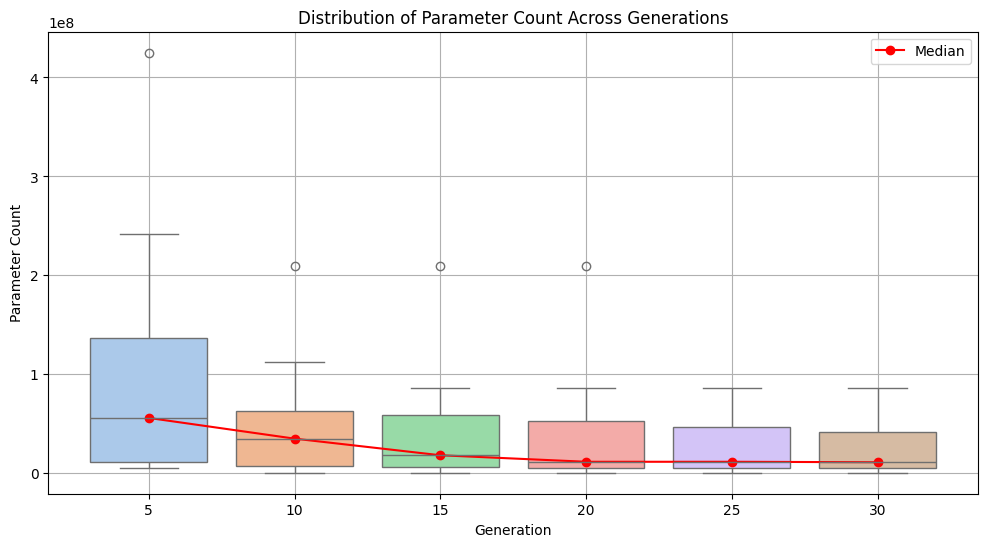

In [ ]:
# Plot for Parameter Count Objective
plt.figure(figsize=(12, 6))
sns.boxplot(data=param_count_data, palette="pastel")
plt.plot(range(len(selected_gens)), param_count_medians, marker='o', linestyle='-', color='red', label='Median')
plt.xticks(range(len(selected_gens)), selected_gens)
plt.title('Distribution of Parameter Count Across Generations')
plt.xlabel('Generation')
plt.ylabel('Parameter Count')
plt.legend()
plt.grid(True)
plt.show()

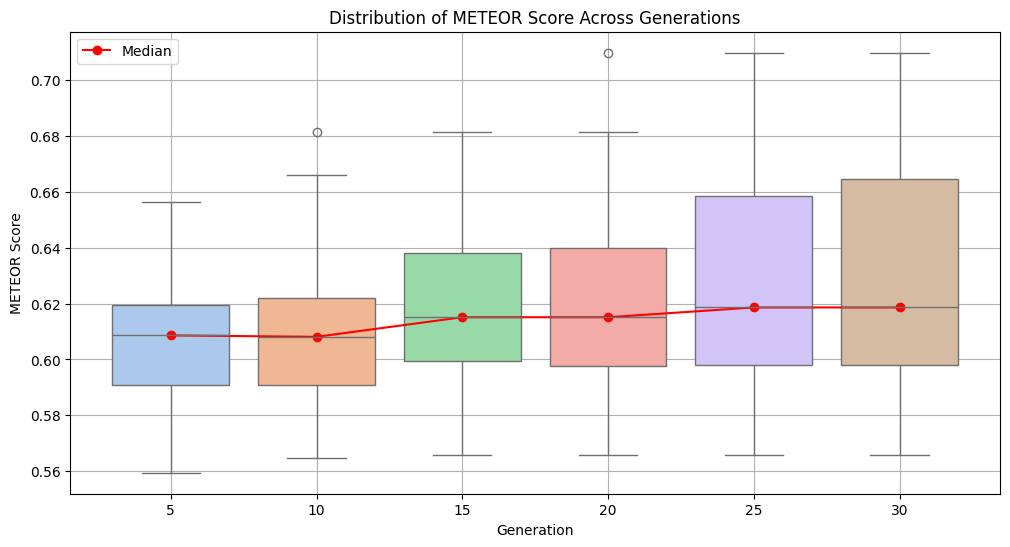

In [ ]:
# Plot for METEOR Score Objective
plt.figure(figsize=(12, 6))
sns.boxplot(data=meteor_data, palette="pastel")
plt.plot(range(len(selected_gens)), meteor_medians, marker='o', linestyle='-', color='red', label='Median')
plt.xticks(range(len(selected_gens)), selected_gens)
plt.title('Distribution of METEOR Score Across Generations')
plt.xlabel('Generation')
plt.ylabel('METEOR Score')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Determine the maximum number of generations
max_generations = max(len(fitness) for fitness in all_best_fitness)
generations = range(1, max_generations + 1)


# Initialize lists to store mean and std of param counts and meteor scores
mean_param_counts = []
std_param_counts = []
mean_meteor_scores = []
std_meteor_scores = []

# Calculate means and stds for each generation across experiments
for gen in generations:
    param_counts = [exp[gen - 1][0] for exp in all_best_fitness if gen <= len(exp)]
    meteor_scores = [exp[gen - 1][1] for exp in all_best_fitness if gen <= len(exp)]

    mean_param_counts.append(np.mean(param_counts))
    std_param_counts.append(np.std(param_counts))

    mean_meteor_scores.append(np.mean(meteor_scores))
    std_meteor_scores.append(np.std(meteor_scores))

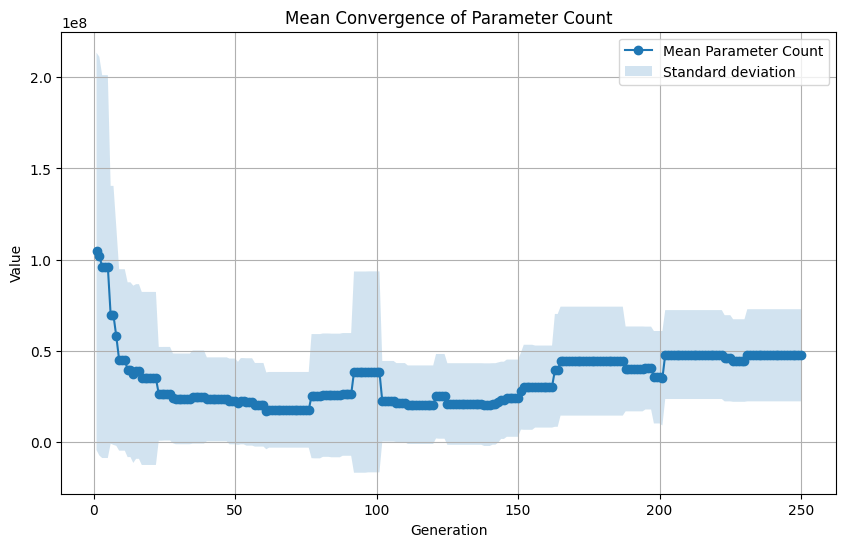

In [ ]:
# Plot mean param count
plt.figure(figsize=(10, 6))
plt.plot(generations, mean_param_counts, label='Mean Parameter Count', marker='o')
plt.fill_between(generations, np.array(mean_param_counts) - np.array(std_param_counts),
                 np.array(mean_param_counts) + np.array(std_param_counts), alpha=0.2, label='Standard deviation')
plt.xlabel('Generation')
plt.ylabel('Value')
plt.title('Mean Convergence of Parameter Count')
plt.legend()
plt.grid(True)
plt.show()

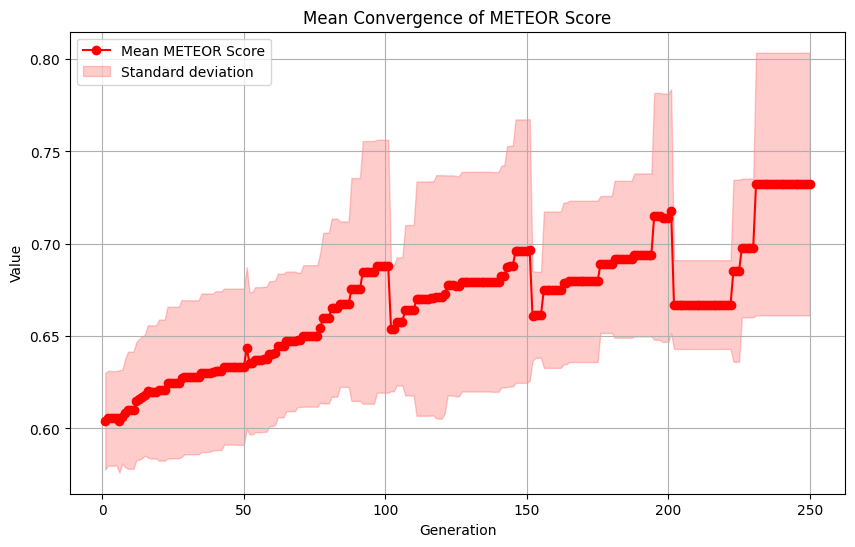

In [ ]:
# Plot mean METEOR score
plt.figure(figsize=(10, 6))
plt.plot(generations, mean_meteor_scores, label='Mean METEOR Score', marker='o', color='red')
plt.fill_between(generations, np.array(mean_meteor_scores) - np.array(std_meteor_scores),
                 np.array(mean_meteor_scores) + np.array(std_meteor_scores), alpha=0.2, label='Standard deviation', color='red')
plt.xlabel('Generation')
plt.ylabel('Value')
plt.title('Mean Convergence of METEOR Score')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
reference_point = calculate_reference_point(best_models, ["min", "max"])
best_model = select_best_individuals(best_models, ["min", "max"], reference_point, 1)

print(f'Best model is: {best_model}')

Best model is: [{'individual': [128, 512, 48, 64, 0.0, 0.3, 0.0], 'fitness': [np.float32(15947904.0), np.float64(0.8691268725584407)]}]


In [ ]:
# Decode the individual into a PyTorch model
best_model_decoded = network_decode(best_model[0]['individual'])


# Export the model to a .pkl file in Google Drive
drive_path = '/content/drive/MyDrive/NAS/Israel/config_3/best_model.pkl'

with open(drive_path, 'wb') as f:
    pickle.dump(best_model_decoded, f)

print(f"Best model saved to: {drive_path}")

Activation function is gelu
Best model saved to: /content/drive/MyDrive/NAS/Israel/config_3/best_model.pkl


### Config 4

In [ ]:
for i in range(1):
  print(f'\nRunning experiment for gif creation')

  best_element, _, _, gens_dict = sms_modes(
      [count_distilgpt2_params, estimate_meteor],
      [(8, 4544), (512, 1024), (2, 48), (4, 64), (0.0, 0.3), (0.0, 0.3), (0.0, 1.0)],
      repair_architecture,
      n_var=7,
      n_obj=2,
      gens=500,
      mu=400,
      F=2.0,
      auto_adapt=True,
      nas=True,
      save_progress=True
  )

  print("The best individual is", best_element)


Running experiment for gif creation
Using device: cpu


Generations: 100%|██████████| 500/500 [31:43<00:00,  3.81s/it]

The best individual is [{'individual': [128, 512, 48, 64, 0.0, 0.3, np.float32(0.2274288)], 'fitness': [np.float32(15947904.0), np.float64(0.8763949657143744)]}]


In [ ]:
create_gif("drive/MyDrive/NAS/Israel/config_4", gens_dict)

🔥 Animation saved as pareto_evolution.gif
📊 Hypervolume plot saved.


In [ ]:
best_models_path = "drive/MyDrive/NAS/Israel/config_4/best_models.pkl"
all_best_fitness_path = "drive/MyDrive/NAS/Israel/config_4/all_best_fitness.pkl"
F_arr_path = "drive/MyDrive/NAS/Israel/config_4/F_arr.pkl"

In [ ]:
for i in range(10):
  print(f'\nRunning experiment {i + 1}')

  best_element, best_fitness_per_gen, Fs, _ = sms_modes(
      [count_distilgpt2_params, estimate_meteor],
      [(8, 4544), (512, 1024), (2, 48), (4, 64), (0.0, 0.3), (0.0, 0.3), (0.0, 1.0)],
      repair_architecture,
      n_var=7,
      n_obj=2,
      gens=250,
      mu=400,
      F=2.0,
      auto_adapt=True,
      nas=True,
      early_conv=True
  )

  print("The best individual is", best_element)

  with open(best_models_path, 'ab') as f:
    pickle.dump(best_element[0], f)

  with open(all_best_fitness_path, 'ab') as f:
    pickle.dump(best_fitness_per_gen, f)

  with open(F_arr_path, 'ab') as f:
    pickle.dump(Fs, f)


Running experiment 1
Using device: cpu


Generations:   0%|          | 1/250 [00:05<22:04,  5.32s/it]

(0.7) <= 0.6611930334391266 <= (1.0)


Generations:  20%|██        | 50/250 [03:13<12:54,  3.87s/it]

(0.7) <= 0.7247136232794242 <= (1.0)
Convergence reached, stopping early
The best individual is [{'individual': [256, 512, 48, 64, 0.0, np.float32(0.2526377), np.float64(0.9718913866858646)], 'fitness': [np.float32(50770176.0), np.float64(0.7247136232794242)]}]

Running experiment 2
Using device: cpu


...

(0.7) <= 0.6364839025013843 <= (1.0)


Generations:  20%|██        | 51/250 [03:13<11:44,  3.54s/it]

(0.7) <= 0.6795280795326829 <= (1.0)


Generations:  40%|████      | 100/250 [06:21<09:31,  3.81s/it]

(0.7) <= 0.8691268725584407 <= (1.0)
Convergence reached, stopping early
The best individual is [{'individual': [128, 512, 48, 64, 0.0, 0.3, 0.0], 'fitness': [np.float32(15947904.0), np.float64(0.8691268725584407)]}]


In [ ]:
best_models = []
all_best_fitness = []
F_arr = []

with open(best_models_path, 'rb') as f:
  while True:
    try:
      mod = pickle.load(f)
      best_models.append(mod)
    except EOFError:
      break

with open(all_best_fitness_path, 'rb') as f:
  while True:
    try:
      fit = pickle.load(f)
      all_best_fitness.append(fit)
    except EOFError:
      break

with open(F_arr_path, 'rb') as f:
  while True:
    try:
      F = pickle.load(f)
      F_arr.append(F)
    except EOFError:
      break

print(best_models)
print(all_best_fitness)
print(F_arr)

[{'individual': [256, 512, 48, 64, 0.0, np.float32(0.2526377), np.float64(0.9718913866858646)], 'fitness': [np.float32(50770176.0), np.float64(0.7247136232794242)]}, {'individual': [128, 512, 48, 64, 0.0, 0.3, 1.0], 'fitness': [np.float32(15947904.0), np.float64(0.7804862203146757)]}, {'individual': [128, 512, 48, 64, np.float32(0.010180539), np.float64(0.20444652961005486), 0.0], 'fitness': [np.float32(15947904.0), np.float64(0.7509271446597077)]}, {'individual': [256, 512, 48, 64, 0.0, 0.3, 1.0], 'fitness': [np.float32(50770176.0), np.float64(0.7725482759203353)]}, {'individual': [128, 512, 48, 64, np.float32(0.15342894), np.float32(0.28781942), np.float32(0.31093493)], 'fitness': [np.float32(15947904.0), np.float64(0.7421165029309247)]}, {'individual': [128, 512, 48, 64, np.float64(0.05248209550440847), 0.3, 0.0], 'fitness': [np.float32(15947904.0), np.float64(0.84190007361416)]}, {'individual': [128, 512, 48, 4, 0.0, 0.0, 0.0], 'fitness': [np.float32(15947904.0), np.float64(0.67700

In [ ]:
# Determine the maximum number of generations
max_generations = max(len(fitness) for fitness in all_best_fitness)
generations = range(1, max_generations + 1)


# Initialize lists to store mean and std of F
mean_F = []
std_F = []

# Calculate means and stds for each generation across experiments
for gen in generations:
    F = [exp[gen - 1] for exp in F_arr if gen <= len(exp)]

    mean_F.append(np.mean(F))
    std_F.append(np.std(F))

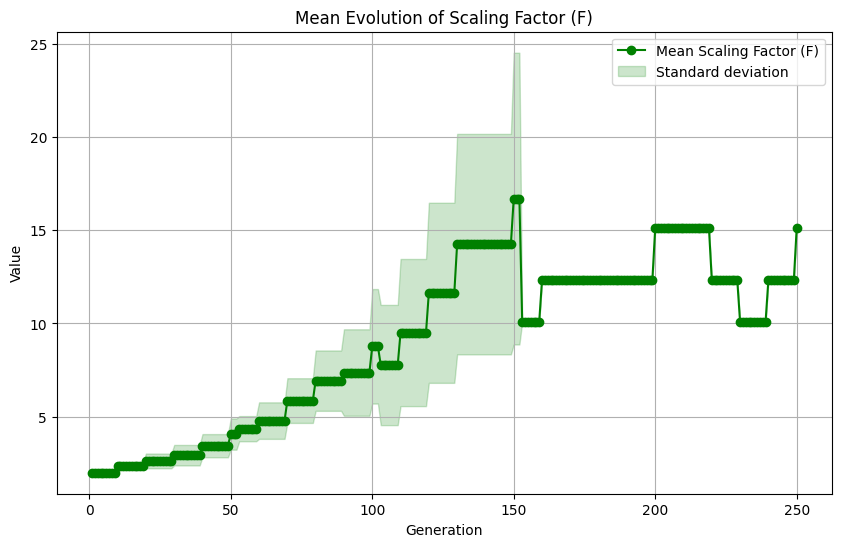

In [ ]:
# Plot mean F evolution
plt.figure(figsize=(10, 6))
plt.plot(generations, mean_F, label='Mean Scaling Factor (F)', marker='o', color='green')
plt.fill_between(generations, np.array(mean_F) - np.array(std_F),
                 np.array(mean_F) + np.array(std_F), alpha=0.2, label='Standard deviation', color='green')
plt.xlabel('Generation')
plt.ylabel('Value')
plt.title('Mean Evolution of Scaling Factor (F)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
selected_gens = [5, 10, 15, 20, 30]
param_count_vals = {gen: [] for gen in selected_gens}
meteor_vals = {gen: [] for gen in selected_gens}

# Extract param count and meteor vals for each selected generation
for exp in all_best_fitness[:20]:
  for gen in selected_gens:
    param_count_vals[gen].append(exp[gen - 1][0])
    meteor_vals[gen].append(exp[gen - 1][1])

# Convert to lists for sns
param_count_data = [param_count_vals[gen] for gen in selected_gens]
meteor_data = [meteor_vals[gen] for gen in selected_gens]

# Compute medians for overlaying trend lines
param_count_medians = [np.median(param_count_vals[gen]) for gen in selected_gens]
meteor_medians = [np.median(meteor_vals[gen]) for gen in selected_gens]

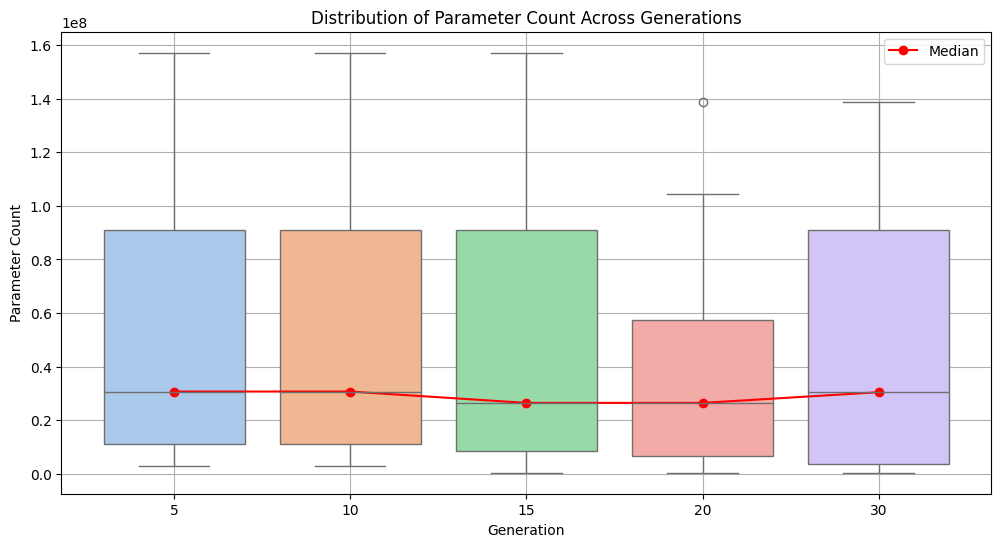

In [ ]:
# Plot for Parameter Count Objective
plt.figure(figsize=(12, 6))
sns.boxplot(data=param_count_data, palette="pastel")
plt.plot(range(len(selected_gens)), param_count_medians, marker='o', linestyle='-', color='red', label='Median')
plt.xticks(range(len(selected_gens)), selected_gens)
plt.title('Distribution of Parameter Count Across Generations')
plt.xlabel('Generation')
plt.ylabel('Parameter Count')
plt.legend()
plt.grid(True)
plt.show()

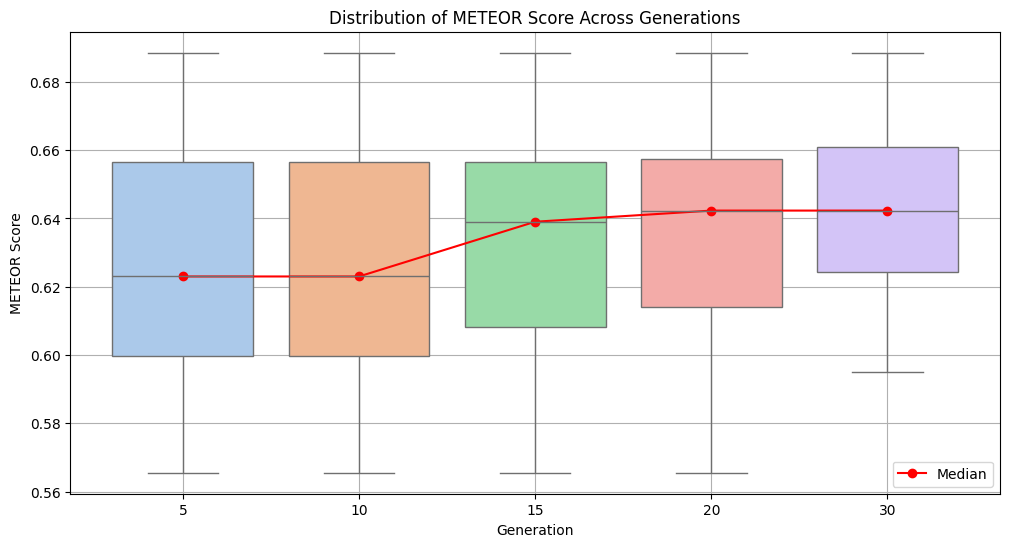

In [ ]:
# Plot for METEOR Score Objective
plt.figure(figsize=(12, 6))
sns.boxplot(data=meteor_data, palette="pastel")
plt.plot(range(len(selected_gens)), meteor_medians, marker='o', linestyle='-', color='red', label='Median')
plt.xticks(range(len(selected_gens)), selected_gens)
plt.title('Distribution of METEOR Score Across Generations')
plt.xlabel('Generation')
plt.ylabel('METEOR Score')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Determine the maximum number of generations
max_generations = max(len(fitness) for fitness in all_best_fitness)
generations = range(1, max_generations + 1)


# Initialize lists to store mean and std of param counts and meteor scores
mean_param_counts = []
std_param_counts = []
mean_meteor_scores = []
std_meteor_scores = []

# Calculate means and stds for each generation across experiments
for gen in generations:
    param_counts = [exp[gen - 1][0] for exp in all_best_fitness if gen <= len(exp)]
    meteor_scores = [exp[gen - 1][1] for exp in all_best_fitness if gen <= len(exp)]

    mean_param_counts.append(np.mean(param_counts))
    std_param_counts.append(np.std(param_counts))

    mean_meteor_scores.append(np.mean(meteor_scores))
    std_meteor_scores.append(np.std(meteor_scores))

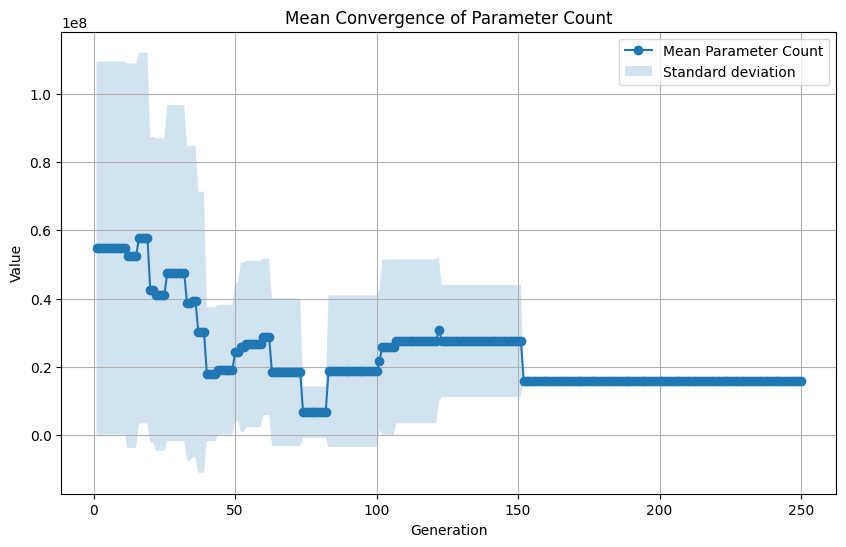

In [ ]:
# Plot mean param count
plt.figure(figsize=(10, 6))
plt.plot(generations, mean_param_counts, label='Mean Parameter Count', marker='o')
plt.fill_between(generations, np.array(mean_param_counts) - np.array(std_param_counts),
                 np.array(mean_param_counts) + np.array(std_param_counts), alpha=0.2, label='Standard deviation')
plt.xlabel('Generation')
plt.ylabel('Value')
plt.title('Mean Convergence of Parameter Count')
plt.legend()
plt.grid(True)
plt.show()

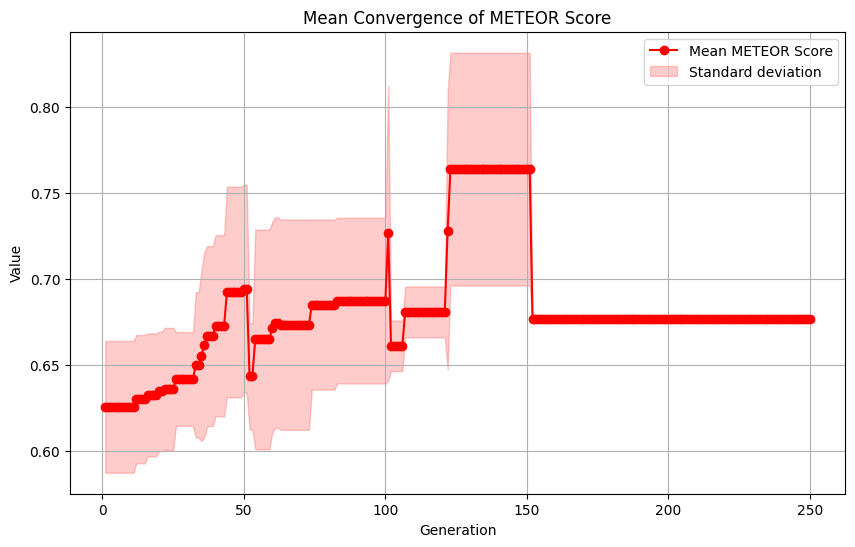

In [ ]:
# Plot mean METEOR score
plt.figure(figsize=(10, 6))
plt.plot(generations, mean_meteor_scores, label='Mean METEOR Score', marker='o', color='red')
plt.fill_between(generations, np.array(mean_meteor_scores) - np.array(std_meteor_scores),
                 np.array(mean_meteor_scores) + np.array(std_meteor_scores), alpha=0.2, label='Standard deviation', color='red')
plt.xlabel('Generation')
plt.ylabel('Value')
plt.title('Mean Convergence of METEOR Score')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
reference_point = calculate_reference_point(best_models, ["min", "max"])
best_model = select_best_individuals(best_models, ["min", "max"], reference_point, 1)

print(f'Best model is: {best_model}')

Best model is: [{'individual': [128, 512, 48, 64, 0.0, 0.3, 0.0], 'fitness': [np.float32(15947904.0), np.float64(0.8691268725584407)]}]


In [ ]:
# Decode the individual into a PyTorch model
best_model_decoded = network_decode(best_model[0]['individual'])


# Export the model to a .pkl file in Google Drive
drive_path = '/content/drive/MyDrive/NAS/Israel/config_4/best_model.pkl'

with open(drive_path, 'wb') as f:
    pickle.dump(best_model_decoded, f)

print(f"Best model saved to: {drive_path}")

Activation function is gelu
Best model saved to: /content/drive/MyDrive/NAS/Israel/config_4/best_model.pkl


## Model

In [ ]:
chrom = [64, 512, 48, 32, 0.0, 0.2, 0.3]

# Decode the individual into a PyTorch model
model_decoded = network_decode(chrom)


# Export the model to a .pkl file in Google Drive
drive_path = '/content/drive/MyDrive/NAS/Israel/config_2/best_model_mid.pkl'

with open(drive_path, 'wb') as f:
    pickle.dump(model_decoded, f)

print(f"Best model saved to: {drive_path}")

Activation function is relu
Best model saved to: /content/drive/MyDrive/NAS/Israel/config_2/best_model_mid.pkl
